# Sample Graphics for Story 1 — Toronto’s Cultural Infrastructure Across Ward Lines

| | |
|---|---|
| **Purpose** | Presentation-ready Matplotlib mockups for Story 1, built from the analysis in `explore_story1_city_reach.ipynb`. Figures are sized to paste directly into a Google Doc (7.5 in wide). |
| **Inputs** | `data/census/wards/toronto-wards.csv`, `data/activity/wards/ward_to_*.csv`, `data/activity/venues_homes.csv`, `src/data/geo/city-wards.geo.json`, `src/data/venues/venues-centroids.geo.json` |
| **Outputs** | Inline figures and tables only. Nothing is written to disk. |
| **Kernel** | `py312` |

## The story in one paragraph

Toronto’s cultural venues function as a shared network. Residents frequently cross ward boundaries, wards play different roles as origins and destinations, and nearby public infrastructure can operate as part of this cultural system. Scarborough provides a focused example of an emerging suburban network.

**Reading order:** (1) citywide cross-ward participation → (2) wards as origins and destinations, with a distance companion → (3) Scarborough as an emerging suburban network, partly supported by public infrastructure.

## Caveats that apply to every figure

- **Normalized activity is not attendance**, a unique-person count or a percentage of residents participating.
- The activity analysis covers **105 selected venues**. The broader inventory holds roughly **2,576 locations** with no comparable activity measurements.
- **Straight-line distance** is not route distance, travel time or difficulty.
- Cultural workers (Story 2) are counted by **home ward, not workplace**; here, activity is attributed to residents’ inferred home ward.
- Ward-level relationships are **ecological**: they describe wards, not individual behaviour, and do not establish causality.

## Visual language (shared with the Story 2 notebook)

Colours come from the Okabe–Ito colourblind-safe palette. **Region colours** (squares beside ward names): Toronto and East York = blue, Etobicoke York = orange, North York = green, Scarborough = purple. **Within home ward** = grey; **outside home ward** = vermillion. **Case-study wards** sit on a pale gold band with bold labels. All colours and sizes live in the configuration cell.

In [1]:
import json
import textwrap
import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pygeohash as pgh
import seaborn as sns
from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch, Patch, Rectangle
from matplotlib.ticker import FuncFormatter
from tqdm.auto import tqdm

%matplotlib inline
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
# ============================================================================
# CONFIGURATION: paths, definitions, colours, highlighted wards, plot parameters
# ============================================================================

# ---- paths (repo root = first ancestor holding sibling data/ and analysis/) ------
REPO_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "data").is_dir() and (p / "analysis").is_dir())
DATA = REPO_ROOT / "data"
SRC_DATA = REPO_ROOT / "src" / "data"

WARD_CENSUS_CSV = DATA / "census" / "wards" / "toronto-wards.csv"
WARD_GEOJSON = SRC_DATA / "geo" / "city-wards.geo.json"
VENUES_HOMES_CSV = DATA / "activity" / "venues_homes.csv"
VENUE_METRICS_JSON = SRC_DATA / "activity" / "venue_metrics.json"
VENUE_CENTROIDS_GEOJSON = SRC_DATA / "venues" / "venues-centroids.geo.json"
BROADER_INVENTORY_CSV = DATA / "venues" / "tac-list" / "current_toronto_arts_locations_eddit.csv"

WARDS_ACTIVITY_DIR = DATA / "activity" / "wards"
WARD_TO_VENUE_ACTIVITY_CSV = WARDS_ACTIVITY_DIR / "ward_to_venue_activity.csv"
WARD_TO_VENUE_SUMMARY_CSV = WARDS_ACTIVITY_DIR / "ward_to_venue_summary.csv"
WARD_TO_WARD_ACTIVITY_CSV = WARDS_ACTIVITY_DIR / "ward_to_ward_activity.csv"
WARD_TO_WARD_SUMMARY_CSV = WARDS_ACTIVITY_DIR / "ward_to_ward_summary.csv"
WARD_TO_WARD_MATRIX_CSV = WARDS_ACTIVITY_DIR / "ward_to_ward_matrix.csv"

# ---- analysis parameters (same definitions as explore_story1_city_reach.ipynb) ----
TIME_PERIOD = "all"                                # headline results use the undivided "all" period
VALUE_COL = "normalized_raw_stop_count_by_ward"    # normalized, ward-mapped activity
MERIDIAN_VENUE_NAMES = ["Meridian Arts Centre"]

# City of Toronto Community Council areas = the four regions
WARD_REGION = {
    "Etobicoke North": "Etobicoke York", "Etobicoke Centre": "Etobicoke York",
    "Etobicoke-Lakeshore": "Etobicoke York", "York South-Weston": "Etobicoke York",
    "York Centre": "Etobicoke York", "Humber River-Black Creek": "Etobicoke York",
    "Eglinton-Lawrence": "Etobicoke York",
    "Parkdale-High Park": "Toronto and East York", "Davenport": "Toronto and East York",
    "Spadina-Fort York": "Toronto and East York", "University-Rosedale": "Toronto and East York",
    "Toronto-St. Paul's": "Toronto and East York", "Toronto Centre": "Toronto and East York",
    "Toronto-Danforth": "Toronto and East York", "Beaches-East York": "Toronto and East York",
    "Don Valley West": "North York", "Don Valley East": "North York",
    "Don Valley North": "North York", "Willowdale": "North York",
    "Scarborough Southwest": "Scarborough", "Scarborough Centre": "Scarborough",
    "Scarborough-Agincourt": "Scarborough", "Scarborough North": "Scarborough",
    "Scarborough-Guildwood": "Scarborough", "Scarborough-Rouge Park": "Scarborough",
}
REGION_ORDER = ["Toronto and East York", "Etobicoke York", "North York", "Scarborough"]
SUBURBAN_REGIONS = REGION_ORDER[1:]
SCARBOROUGH_WARDS = [w for w, r in WARD_REGION.items() if r == "Scarborough"]
DOWNTOWN_CORE_WARDS = [w for w, r in WARD_REGION.items() if r == "Toronto and East York"]

# ---- role classification (median split on the two outside-ward shares) ----------
ROLE_LABELS = {
    "mutual exchange hub": "Mutual-exchange hubs",
    "citywide destination": "Citywide destinations",
    "exporter of activity": "Exporters of activity",
    "primarily local": "Primarily local wards",
}

# ---- Scarborough destination buckets (fixed order, left to right) ---------------
SCARB_BUCKETS = ["same ward", "other Scarborough", "North York / Willowdale", "downtown", "elsewhere in Toronto"]
SCARB_BUCKET_LABELS = {
    "same ward": "Within home ward",
    "other Scarborough": "Another Scarborough ward",
    "North York / Willowdale": "North York / Willowdale",
    "downtown": "Downtown / core",
    "elsewhere in Toronto": "Elsewhere in Toronto",
}

# ---- colour language (Okabe-Ito based, colourblind-safe; shared by both notebooks) ----
INK, MUTED, GRID_COLOR, SURFACE = "#1F2933", "#5F6B76", "#E3E7EB", "#FFFFFF"
REGION_COLORS = {
    "Toronto and East York": "#0072B2",   # blue
    "Etobicoke York": "#E69F00",          # orange
    "North York": "#009E73",              # bluish green
    "Scarborough": "#CC79A7",             # reddish purple
}
WITHIN_COLOR = "#B4BCC4"       # activity inside the home ward (neutral grey)
OUTSIDE_COLOR = "#D55E00"      # activity outside the home ward (vermillion)
OUTSIDE_COLOR_LIGHT = "#EBA97A"
ORIGIN_COLOR = OUTSIDE_COLOR   # "residents' activity occurring outside" (origin side)
DEST_COLOR = "#3B2F8F"         # "venue activity coming from outside" (destination side, indigo)
LINK_COLOR = "#C5CCD3"
HIGHLIGHT_BAND = "#FFF1B8"     # case-study wards: pale gold band + bold label
NEUTRAL_FILL = "#D9DEE3"
SCARB_BUCKET_COLORS = {
    "same ward": WITHIN_COLOR,
    "other Scarborough": REGION_COLORS["Scarborough"],
    "North York / Willowdale": REGION_COLORS["North York"],
    "downtown": REGION_COLORS["Toronto and East York"],
    "elsewhere in Toronto": "#EDE6D6",
}
FLOW_COLOR = "#8E3B73"
HALO = [pe.withStroke(linewidth=2.6, foreground=SURFACE)]      # white outline so labels stay legible over lines and fills
QUADRANT_TINTS = {"mutual exchange hub": "#F4F6F8", "primarily local": "#F4F6F8",      # neutral tints, so the groups are not read as good/bad
                  "citywide destination": "#E8ECEF", "exporter of activity": "#E8ECEF"}
MAP_CONTEXT_FILL, MAP_SCARB_FILL = "#F1F3F5", "#E9DCE4"

# ---- highlighted wards, labelled examples, venues of interest ------------------
HIGHLIGHT_WARDS = ["Don Valley West", "Willowdale", "Scarborough North", "Scarborough Southwest"]
QUADRANT_LABELLED = [
    "Don Valley West", "Willowdale", "Scarborough North", "Scarborough Southwest",
    "University-Rosedale", "York South-Weston", "Don Valley East",
]
# manual label offsets (points) for the quadrant scatter: ward -> (dx, dy, horizontal alignment)
QUADRANT_LABEL_OFFSETS = {
    "Don Valley West": (-6, 6, "right"), "Willowdale": (7, 4, "left"),
    "Scarborough North": (7, -9, "left"), "Scarborough Southwest": (-6, -10, "right"),
    "University-Rosedale": (7, 4, "left"), "York South-Weston": (-6, -10, "right"),
    "Don Valley East": (6, 6, "left"), "Spadina-Fort York": (7, -9, "left"),
}
# venues to place on the flow map: exact venue_name -> (short label, dx, dy in points, alignment)
SCARB_MAP_VENUES = {
    "Malvern Library": ("Malvern Library", 6, 26, "center"),
    "Scarborough Civic Centre Library": ("Scarborough Civic\nCentre Library", 50, 26, "left"),
    "Birkdale Community Centre": ("Birkdale\nCommunity Centre", 36, -40, "left"),
    "Agincourt Toronto Public Library": ("Agincourt TPL", -38, -8, "right"),
    "P.C. Ho Theatre": ("P.C. Ho Theatre", 40, -12, "left"),
    "Woodside Square Cinemas": ("Woodside Square\nCinemas", -34, 30, "right"),
}
# ward-name label offsets on the flow map (points)
SCARB_MAP_WARD_LABEL_OFFSETS = {
    "Scarborough Southwest": (0, -18), "Scarborough Centre": (-36, -20),
    "Scarborough-Agincourt": (-6, 22), "Scarborough North": (0, 20),
    "Scarborough-Guildwood": (4, 19), "Scarborough-Rouge Park": (0, -19),
}
# arc curvature (arc3 rad) for flows that would otherwise pass through another ward node
FLOW_MAP_RAD = {("Scarborough Southwest", "Scarborough-Agincourt"): -0.3}
FLOW_MAP_DEFAULT_RAD = 0.14
FLOW_MAP_TOP_N = 6             # strongest Scarborough-internal flows drawn
FLOW_MAP_MAX_LW = 5.5          # line width (pt) of the strongest flow
FLOW_MAP_NODE_AREA = (50, 450) # marker-area range (pt^2) for node size

# ---- figure format (copy-paste ready for a Google Doc: ~6.5-7.5 in wide) -------
FIG_W = 7.5
FIG_DPI = 150
TITLE_SIZE, SUBTITLE_SIZE, LABEL_SIZE, TICK_SIZE, NOTE_SIZE = 12.5, 8.8, 9, 8.3, 7
RC_PARAMS = {
    "figure.dpi": FIG_DPI, "savefig.dpi": FIG_DPI, "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE, "axes.edgecolor": MUTED, "axes.labelcolor": INK,
    "axes.labelsize": LABEL_SIZE, "xtick.labelsize": TICK_SIZE, "ytick.labelsize": TICK_SIZE,
    "xtick.color": MUTED, "ytick.color": INK, "text.color": INK, "font.size": 9,
    "axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False,
    "legend.fontsize": 8, "axes.grid": False,
}
plt.rcParams.update(RC_PARAMS)
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

# ---- expected values from the brief, used ONLY as validation targets: name -> (value, tolerance) ----
EXPECTED = {
    "citywide outside-ward share": (0.520, 0.0006),
    "wards with outside share > 50% (of 25)": (20, 0),
    "median ward outside share": (0.776, 0.0006),
    "role count: mutual exchange hub": (7, 0),
    "role count: citywide destination": (6, 0),
    "role count: exporter of activity": (6, 0),
    "role count: primarily local": (6, 0),
    "Don Valley West: venues' outside-origin share": (0.85, 0.005),
    "median distance, within home ward (km)": (0.3, 0.05),
    "median distance, all cross-ward (km)": (6.2, 0.05),
    "median distance, suburb-to-suburb (km)": (6.6, 0.05),
    "median distance, suburb-to-downtown (km)": (11.3, 0.05),
    "suburban outside-ward activity staying suburban": (0.46, 0.005),
    "Scarborough North -> other Scarborough": (0.383, 0.0006),
    "Scarborough North -> North York/Willowdale": (0.221, 0.0006),
    "Scarborough North -> downtown": (0.201, 0.0006),
    "Scarborough-Agincourt received from other Scarborough": (681, 0.5),
    "Scarborough Centre received from other Scarborough": (447, 0.5),
    "Scarborough North -> Scarborough-Agincourt": (283, 1.5),
    "reciprocity, Scarborough North <-> Agincourt": (0.09, 0.005),
    "Malvern Library share of Scarborough-destination activity": (0.346, 0.0006),
    "other-Scarborough share excluding Malvern Library": (0.553, 0.0006),
    "Scarborough residents' median distance: other Scarborough (km)": (4.3, 0.05),
    "Scarborough residents' median distance: North York/Willowdale (km)": (12.5, 0.05),
    "Scarborough residents' median distance: downtown (km)": (13.5, 0.05),
}

In [3]:
# ============================================================================
# HELPERS
# ============================================================================

# ---- analysis helpers ------------------------------------------------------------
def region_of(ward):
    return "Downtown/core" if ward in DOWNTOWN_CORE_WARDS else WARD_REGION[ward]


def classify_role(origin_outside, dest_outside, med_origin, med_dest):
    high_o, high_d = origin_outside >= med_origin, dest_outside >= med_dest
    if high_o and high_d:
        return "mutual exchange hub"
    if high_o:
        return "exporter of activity"
    if high_d:
        return "citywide destination"
    return "primarily local"


def scarborough_bucket(dest_ward, origin_ward):
    if dest_ward == origin_ward:
        return "same ward"
    if dest_ward in SCARBOROUGH_WARDS:
        return "other Scarborough"
    if WARD_REGION[dest_ward] == "North York":      # includes Willowdale
        return "North York / Willowdale"
    if dest_ward in DOWNTOWN_CORE_WARDS:
        return "downtown"
    return "elsewhere in Toronto"


def weighted_quantiles(df, value_col, weight_col, qs=(0.25, 0.5, 0.75)):
    d = df.sort_values(value_col)
    cum_w = d[weight_col].cumsum() / d[weight_col].sum()
    return {q: float(np.interp(q, cum_w, d[value_col])) for q in qs}


def build_home_distances():
    """Straight-line distance (km) from each home geohash6 centre to each venue, tagged with origin/dest ward.

    Mirrors explore_story1_city_reach.ipynb Section 6 (UTM-projected, ward via point-in-polygon).
    """
    homes = pd.read_csv(VENUES_HOMES_CSV)
    homes = homes[homes["time_period"] == TIME_PERIOD].copy()
    cells = pd.DataFrame({"home_geohash6": homes["home_geohash6"].unique()})
    decoded = [pgh.decode(g) for g in tqdm(cells["home_geohash6"], desc="decoding home geohash6 cells")]
    cells["home_lat"], cells["home_lon"] = [d[0] for d in decoded], [d[1] for d in decoded]
    cell_pts = gpd.GeoDataFrame(cells, geometry=gpd.points_from_xy(cells["home_lon"], cells["home_lat"]), crs="EPSG:4326")
    cell_ward = gpd.sjoin(cell_pts, wards_gdf[["ward_name", "geometry"]], predicate="within")[["home_geohash6", "ward_name"]]
    cell_ward = cell_ward.rename(columns={"ward_name": "origin_ward"})
    cell_xy = cell_pts.to_crs(UTM_CRS)
    cells["easting"], cells["northing"] = cell_xy.geometry.x.values, cell_xy.geometry.y.values
    venue_xy = venue_points.to_crs(UTM_CRS)
    venue_coords = pd.DataFrame({"venue_id": venue_points["venue_id"].values,
                                 "v_easting": venue_xy.geometry.x.values, "v_northing": venue_xy.geometry.y.values})
    out = (homes.merge(cells[["home_geohash6", "easting", "northing"]], on="home_geohash6")
                .merge(venue_coords, on="venue_id")
                .merge(cell_ward, on="home_geohash6", how="left")
                .merge(venue_to_dest_ward[["venue_id", "dest_ward"]], on="venue_id", how="left"))
    out["distance_km"] = np.hypot(out["easting"] - out["v_easting"], out["northing"] - out["v_northing"]) / 1000
    n_unmatched = out["origin_ward"].isna().sum()
    print(f"home cells with no ward match (excluded from distance summaries): {n_unmatched} / {len(out)} rows")
    return out.dropna(subset=["origin_ward", "distance_km"])


def run_checks(rows):
    """rows: list of (name, computed). Compares against EXPECTED (value, tolerance); returns a tidy table."""
    out = []
    for name, value in rows:
        expected, tol = EXPECTED[name]
        out.append({"check": name, "computed": value, "expected": expected,
                    "status": "OK" if abs(value - expected) <= tol + 1e-9 else "CHECK"})
    table = pd.DataFrame(out)
    display(table.style.hide(axis="index").format({"computed": "{:,.3f}", "expected": "{:,.3f}"}))
    n_bad = (table["status"] != "OK").sum()
    print(f"{len(table) - n_bad}/{len(table)} validation checks within tolerance" + ("" if n_bad == 0 else "  <-- diagnose before trusting the figure"))
    return table


# ---- plotting helpers ---------------------------------------------------------------
def pct_fmt():
    return FuncFormatter(lambda v, _: f"{v:.0f}%")


def style_axes(ax, grid_axis="x"):
    ax.grid(axis=grid_axis, color=GRID_COLOR, linewidth=0.7)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID_COLOR)


def title_block(fig, title, subtitle=None, title_wrap=64, sub_wrap=98):
    """Left-aligned wrapped title + muted subtitle at the top of the figure.

    Returns the figure-fraction y of the block's bottom edge, so callers can set subplots_adjust(top=...).
    """
    H = fig.get_figheight()
    t = textwrap.fill(title, title_wrap)
    fig.text(0.015, 1 - 0.07 / H, t, fontsize=TITLE_SIZE, fontweight="bold", ha="left", va="top", linespacing=1.15)
    y = 1 - (0.07 + (t.count("\n") + 1) * TITLE_SIZE * 1.25 / 72 + 0.09) / H
    if subtitle:
        sub = textwrap.fill(subtitle, sub_wrap)
        fig.text(0.015, y, sub, fontsize=SUBTITLE_SIZE, color=MUTED, ha="left", va="top", linespacing=1.35)
        y -= ((sub.count("\n") + 1) * SUBTITLE_SIZE * 1.4 / 72 + 0.06) / H
    return y


def source_note(fig, text, wrap=130, y=0.008):
    fig.text(0.015, y, textwrap.fill(text, wrap), fontsize=NOTE_SIZE, color=MUTED, ha="left", va="bottom", linespacing=1.3)


def region_markers(ax, wards, x=-0.012, size=26):
    """Small coloured squares left of each y tick: the ward's Community Council region."""
    ys = np.arange(len(wards))
    ax.scatter([x] * len(wards), ys, s=size, marker="s", c=[REGION_COLORS[WARD_REGION[w]] for w in wards],
               transform=ax.get_yaxis_transform(), clip_on=False, zorder=5, linewidths=0)


def region_legend(fig, y=0.03, ncol=4, x=0.5):
    handles = [Line2D([0], [0], marker="s", linestyle="", markersize=7, color=REGION_COLORS[r], label=r) for r in REGION_ORDER]
    fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(x, y), ncol=ncol, fontsize=8, handletextpad=0.3, columnspacing=1.2)


def highlight_rows(ax, wards, highlight=HIGHLIGHT_WARDS, x0=-0.40):
    """Pale band behind highlighted ward rows (extends under the tick labels) + bold labels."""
    for i, w in enumerate(wards):
        if w in highlight:
            ax.add_patch(Rectangle((x0, i - 0.5), 1 - x0, 1, transform=ax.get_yaxis_transform(), facecolor=HIGHLIGHT_BAND,
                                   edgecolor="none", clip_on=False, zorder=0))
    for lab in ax.get_yticklabels():
        if lab.get_text() in highlight:
            lab.set_fontweight("bold")

## Data loading and QA

Loading, joins and QA reuse the definitions from the reference notebook: ward names join across all tables without fuzzy matching, the activity tables reconcile with one another, and each venue’s ward agrees with a point-in-polygon check. Expected values from the brief appear only in the validation tables below each calculation; every number on a figure is computed from the source data.

In [4]:
# --- ward census (authoritative ward list) ----------------------------------------------
census_long = pd.read_csv(WARD_CENSUS_CSV)
ward_pop = (census_long.loc[census_long["CHARACTERISTIC_ID"] == 1, ["ward_code", "ward_name", "C1_COUNT_TOTAL"]]
            .rename(columns={"C1_COUNT_TOTAL": "population_2021"}))
ward_pop["region"] = ward_pop["ward_name"].map(WARD_REGION)
assert len(ward_pop) == 25 and ward_pop["region"].notna().all()

# --- ward-level activity tables (same renames as the reference notebook) ----------------
ward_to_venue_activity = pd.read_csv(WARD_TO_VENUE_ACTIVITY_CSV).rename(columns={
    "ward_name": "origin_ward", "venue_ward": "dest_ward", "home_ward": "is_home_ward"})
ward_to_venue_summary = pd.read_csv(WARD_TO_VENUE_SUMMARY_CSV).rename(columns={"home_ward": "dest_ward"})
ward_to_ward_activity = pd.read_csv(WARD_TO_WARD_ACTIVITY_CSV).rename(columns={"ward_name": "origin_ward", "venue_ward": "dest_ward"})
ward_to_ward_summary = pd.read_csv(WARD_TO_WARD_SUMMARY_CSV).rename(columns={"ward_name": "origin_ward"})
ward_to_ward_matrix = pd.read_csv(WARD_TO_WARD_MATRIX_CSV).rename(columns={"ward_name": "origin_ward"}).set_index("origin_ward")

# --- geometry, venue metadata, destination ward per venue -------------------------------
wards_gdf = gpd.read_file(WARD_GEOJSON)
wards_gdf = wards_gdf[wards_gdf.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
if wards_gdf.crs is None:
    wards_gdf = wards_gdf.set_crs("EPSG:4326")
UTM_CRS = wards_gdf.estimate_utm_crs()

with open(VENUE_CENTROIDS_GEOJSON) as f:
    venue_meta = pd.json_normalize([ft["properties"] | {"lon": ft["geometry"]["coordinates"][0], "lat": ft["geometry"]["coordinates"][1]}
                                    for ft in json.load(f)["features"]])
venue_meta["venue_id"] = venue_meta["id"].astype(int)
venue_points = gpd.GeoDataFrame(venue_meta[["venue_id", "venue_name", "lat", "lon"]],
                                geometry=gpd.points_from_xy(venue_meta["lon"], venue_meta["lat"]), crs="EPSG:4326")
venue_to_dest_ward = (ward_to_venue_activity.loc[ward_to_venue_activity["is_home_ward"], ["venue_id", "venue_name", "dest_ward"]]
                      .drop_duplicates())
n_venues = ward_to_venue_activity["venue_id"].nunique()

# --- condensed QA (same checks as the reference notebook) -------------------------------
assert len(wards_gdf) == 25 and n_venues == 105 == venue_meta["venue_id"].nunique() == len(venue_to_dest_ward)
assert set(ward_to_ward_summary["origin_ward"]) == set(ward_pop["ward_name"]) == set(ward_to_ward_matrix.index) == set(ward_to_ward_matrix.columns)
assert ward_to_venue_activity.shape[0] == n_venues * 25, "expected a dense venue x ward cross-join"

matrix_long = ward_to_ward_matrix.reset_index().melt(id_vars="origin_ward", var_name="dest_ward", value_name="matrix_value")
assert (ward_to_ward_activity.merge(matrix_long, on=["origin_ward", "dest_ward"])
        .eval(f"abs({VALUE_COL} - matrix_value)").max() < 1e-6), "matrix and long table disagree"

by_flag = ward_to_ward_activity.groupby(["origin_ward", "same_ward"])[VALUE_COL].sum().unstack()
recon = ward_to_ward_summary.set_index("origin_ward")
assert (recon["normalized_raw_stop_count_within_ward"] - by_flag[True]).abs().max() < 1e-6
assert (recon["normalized_raw_stop_count_outside_ward"] - by_flag[False]).abs().max() < 1e-6
assert ward_to_ward_activity[VALUE_COL].ge(0).all() and ward_to_ward_activity[VALUE_COL].notna().all()

venue_ward_spatial = gpd.sjoin(venue_points, wards_gdf[["ward_name", "geometry"]], predicate="within")[["venue_id", "ward_name"]]
spatial_mismatch = venue_to_dest_ward.merge(venue_ward_spatial, on="venue_id").query("dest_ward != ward_name")
assert spatial_mismatch.empty, "activity-table destination ward disagrees with point-in-polygon ward"

print(f"25 wards | {n_venues} activity venues | {len(ward_to_ward_activity)} origin-destination ward pairs | UTM CRS {UTM_CRS.to_string()}")
print("QA passed: tables reconcile (matrix = long table = summary), venue wards agree with a spatial join, no missing/negative values.")

25 wards | 105 activity venues | 625 origin-destination ward pairs | UTM CRS EPSG:32617
QA passed: tables reconcile (matrix = long table = summary), venue wards agree with a spatial join, no missing/negative values.


## 1. Headline graphic: within-ward versus outside-ward activity

**Claim to support:** crossing ward lines is the norm for arts-venue activity, across Toronto, not an edge case.

Two definitions are used and kept distinct: the **citywide activity-weighted share** (every unit of normalized activity counts once) and the **ward-level count and median** (every ward counts once).

In [5]:
# --- two-sided ward table: origin side (residents) and destination side (venues) ---------
def side_table(group_col):
    """Within/outside shares of activity grouped by `group_col` (origin or destination ward)."""
    g = ward_to_ward_activity.groupby(group_col)
    total = g[VALUE_COL].sum()
    outside = ward_to_ward_activity[~ward_to_ward_activity["same_ward"]].groupby(group_col)[VALUE_COL].sum()
    return total, outside.reindex(total.index).fillna(0)


o_total, o_out = side_table("origin_ward")
d_total, d_out = side_table("dest_ward")
ward_reach = pd.DataFrame({
    "origin_total": o_total, "origin_outside_share": o_out / o_total,
    "dest_total": d_total, "dest_outside_share": d_out / d_total,
}).rename_axis("ward_name").reset_index()
ward_reach["origin_within_share"] = 1 - ward_reach["origin_outside_share"]
ward_reach["region"] = ward_reach["ward_name"].map(WARD_REGION)
ward_reach["n_venues"] = ward_reach["ward_name"].map(venue_to_dest_ward.groupby("dest_ward").size()).fillna(0).astype(int)

# citywide, activity-weighted: every unit of normalized activity counts once
total_within = ward_to_ward_summary["normalized_raw_stop_count_within_ward"].sum()
total_outside = ward_to_ward_summary["normalized_raw_stop_count_outside_ward"].sum()
citywide_outside_share = total_outside / (total_within + total_outside)
n_majority_outside = int((ward_reach["origin_outside_share"] > 0.5).sum())
median_outside_share = ward_reach["origin_outside_share"].median()

# sensitivity: excluding Meridian Arts Centre (dominates Willowdale's within-ward activity)
meridian_ids = venue_meta.loc[venue_meta["venue_name"].isin(MERIDIAN_VENUE_NAMES), "venue_id"]
ex = ward_to_venue_activity[~ward_to_venue_activity["venue_id"].isin(meridian_ids)]
ex_within = ex.loc[ex["is_home_ward"], VALUE_COL].sum()
citywide_outside_share_ex_meridian = 1 - ex_within / ex[VALUE_COL].sum()

# roles: median split on the two outside-ward shares
med_origin, med_dest = ward_reach["origin_outside_share"].median(), ward_reach["dest_outside_share"].median()
ward_reach["role"] = [classify_role(o, d, med_origin, med_dest) for o, d in zip(ward_reach["origin_outside_share"], ward_reach["dest_outside_share"])]
role_counts = ward_reach["role"].value_counts()

dvw = ward_reach.set_index("ward_name").loc["Don Valley West"]
by_region = (ward_reach.assign(majority_outside=ward_reach["origin_outside_share"] > 0.5)
             .groupby("region")["majority_outside"].agg(["sum", "size"]).reindex(REGION_ORDER))
print("wards with a majority outside, by region:", ", ".join(f"{r}: {int(v['sum'])} of {int(v['size'])}" for r, v in by_region.iterrows()))
print(f"citywide activity-weighted outside share: {citywide_outside_share:.1%} (excluding Meridian: {citywide_outside_share_ex_meridian:.1%})")
print(f"wards above 50% outside: {n_majority_outside}/25 | median ward: {median_outside_share:.1%}")
print(f"median destination-side outside share: {med_dest:.1%} | Don Valley West: residents {dvw['origin_outside_share']:.1%} out, venues {dvw['dest_outside_share']:.1%} from outside")

checks_1_2 = run_checks([
    ("citywide outside-ward share", citywide_outside_share),
    ("wards with outside share > 50% (of 25)", n_majority_outside),
    ("median ward outside share", median_outside_share),
    ("role count: mutual exchange hub", role_counts.get("mutual exchange hub", 0)),
    ("role count: citywide destination", role_counts.get("citywide destination", 0)),
    ("role count: exporter of activity", role_counts.get("exporter of activity", 0)),
    ("role count: primarily local", role_counts.get("primarily local", 0)),
    ("Don Valley West: venues' outside-origin share", dvw["dest_outside_share"]),
])

wards with a majority outside, by region: Toronto and East York: 5 of 8, Etobicoke York: 7 of 7, North York: 3 of 4, Scarborough: 5 of 6
citywide activity-weighted outside share: 52.0% (excluding Meridian: 60.8%)
wards above 50% outside: 20/25 | median ward: 77.6%
median destination-side outside share: 53.5% | Don Valley West: residents 99.8% out, venues 85.2% from outside


check,computed,expected,status
citywide outside-ward share,0.520,0.520,OK
wards with outside share > 50% (of 25),20.000,20.000,OK
median ward outside share,0.776,0.776,OK
role count: mutual exchange hub,7.000,7.000,OK
role count: citywide destination,6.000,6.000,OK
role count: exporter of activity,6.000,6.000,OK
role count: primarily local,6.000,6.000,OK
Don Valley West: venues' outside-origin share,0.852,0.850,OK


8/8 validation checks within tolerance


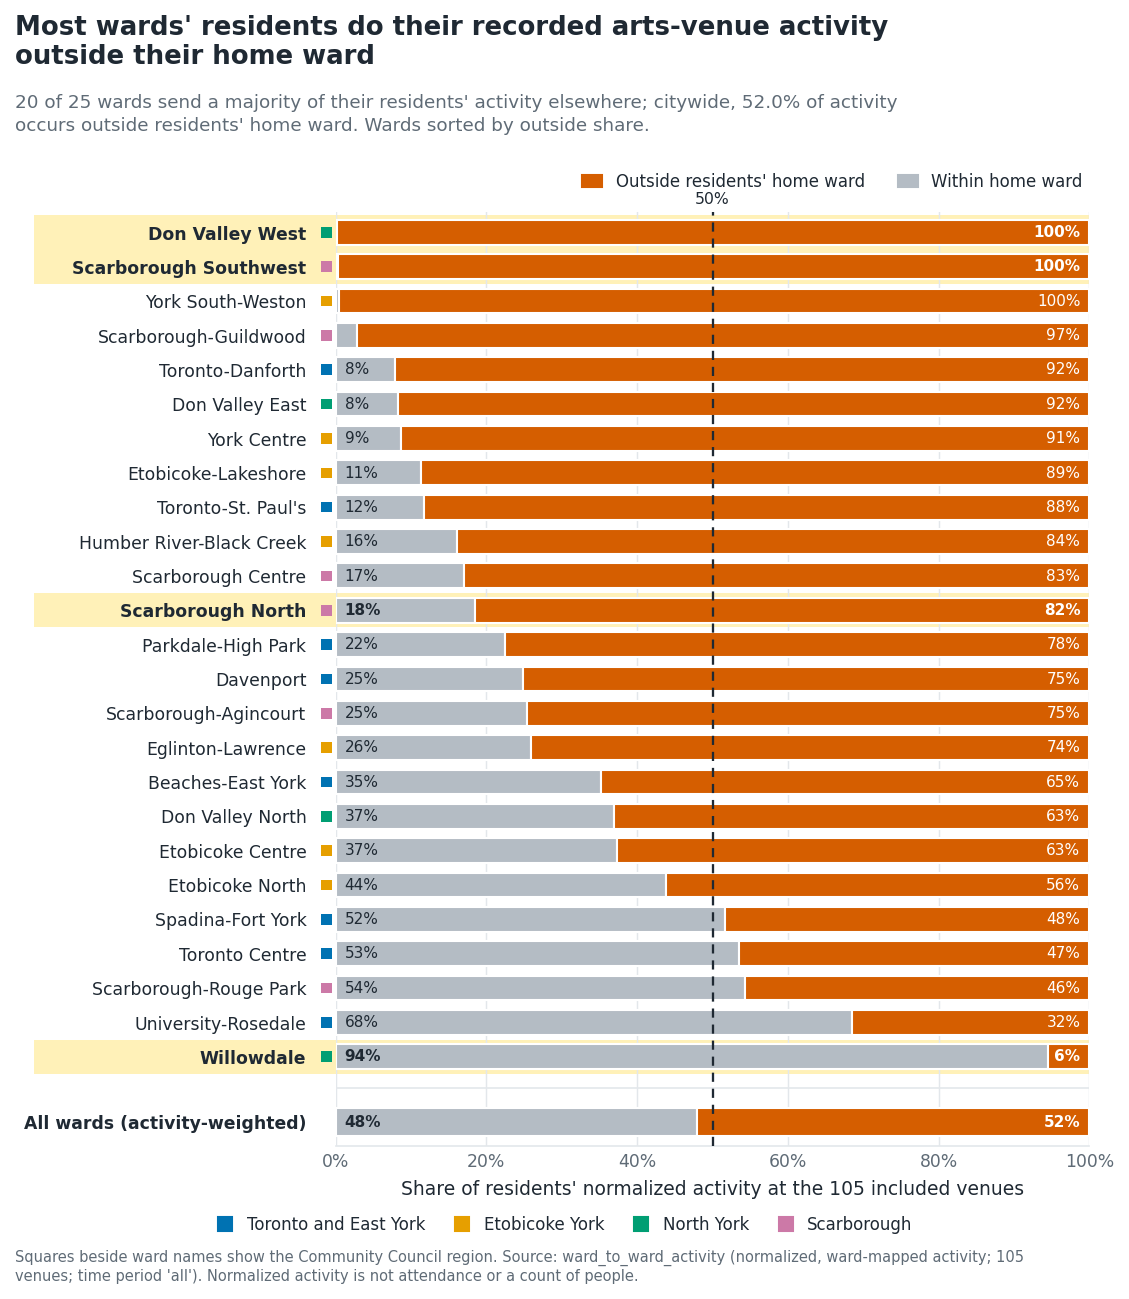

In [6]:
def plot_within_outside_stacked(df):
    d = df.sort_values("origin_outside_share", ascending=True).reset_index(drop=True)   # highest outside share at top
    wards = d["ward_name"].tolist()
    y = np.arange(len(d))
    y_city = -1.9                                                                        # citywide bar sits below a gap

    fig = plt.figure(figsize=(FIG_W, 8.6))
    top = title_block(fig, "Most wards' residents do their recorded arts-venue activity outside their home ward",
                      f"{n_majority_outside} of 25 wards send a majority of their residents' activity elsewhere; citywide, "
                      f"{citywide_outside_share:.1%} of activity occurs outside residents' home ward. Wards sorted by outside share.")
    fig.subplots_adjust(left=0.30, right=0.97, top=top - 0.045, bottom=0.115)
    ax = fig.add_subplot(111)
    ax.set_ylim(y_city - 0.7, len(d) - 0.4)
    ax.set_xlim(0, 100)
    ax.set_yticks(list(y) + [y_city])
    ax.set_yticklabels(wards + ["All wards (activity-weighted)"])
    for i, w in enumerate(wards):
        if w in HIGHLIGHT_WARDS:
            ax.add_patch(Rectangle((-0.40, i - 0.5), 1.40, 1, transform=ax.get_yaxis_transform(), facecolor=HIGHLIGHT_BAND,
                                   edgecolor="none", clip_on=False, zorder=0))

    def draw(yv, within, outside, bold=False, h=0.72):
        ax.barh(yv, within * 100, height=h, color=WITHIN_COLOR, edgecolor=SURFACE, linewidth=1, zorder=2)
        ax.barh(yv, outside * 100, left=within * 100, height=h, color=OUTSIDE_COLOR, edgecolor=SURFACE, linewidth=1, zorder=2)
        weight = "bold" if bold else "normal"
        if within >= 0.05:      # labels sit at the bar ends so they never collide with the 50% line
            ax.text(1.2, yv, f"{within:.0%}", ha="left", va="center", fontsize=7.3, color=INK, fontweight=weight, zorder=3)
        if outside >= 0.05:
            ax.text(98.8, yv, f"{outside:.0%}", ha="right", va="center", fontsize=7.3, color="white", fontweight=weight, zorder=3)

    for yi, row in zip(y, d.itertuples()):
        draw(yi, row.origin_within_share, row.origin_outside_share, bold=row.ward_name in HIGHLIGHT_WARDS)
    draw(y_city, 1 - citywide_outside_share, citywide_outside_share, bold=True, h=0.8)

    ax.axvline(50, color=INK, linestyle=(0, (4, 3)), linewidth=1.1, zorder=4)
    ax.text(50, len(d) - 0.25, "50%", ha="center", va="bottom", fontsize=7.5, color=INK, clip_on=False)
    ax.axhline(y_city + 1.0, color=GRID_COLOR, linewidth=0.8)
    for lab in ax.get_yticklabels():
        if lab.get_text() in HIGHLIGHT_WARDS or lab.get_text().startswith("All wards"):
            lab.set_fontweight("bold")
    ax.tick_params(axis="y", pad=14)
    region_markers(ax, wards, x=-0.012)
    ax.xaxis.set_major_formatter(pct_fmt())
    ax.set_xlabel("Share of residents' normalized activity at the 105 included venues")
    style_axes(ax, "x")
    ax.spines["left"].set_visible(False)
    handles = [Patch(color=OUTSIDE_COLOR, label="Outside residents' home ward"), Patch(color=WITHIN_COLOR, label="Within home ward")]
    ax.legend(handles=handles, loc="lower right", bbox_to_anchor=(1.0, 1.015), ncol=2, fontsize=8, handlelength=1.2, borderaxespad=0)
    region_legend(fig, y=0.035)
    source_note(fig, "Squares beside ward names show the Community Council region. Source: ward_to_ward_activity (normalized, ward-mapped activity; "
                     "105 venues; time period 'all'). Normalized activity is not attendance or a count of people.", wrap=135)
    plt.show()


plot_within_outside_stacked(ward_reach)

**What it shows.** For each of the 25 wards, the split of residents’ normalized activity at the 105 included venues between venues inside their home ward (grey) and elsewhere (vermillion). The bottom bar is the citywide activity-weighted split.

**Narrative claim.** Cross-ward use is a **cross-city phenomenon**, not a downtown-only or Scarborough-only finding. 52.0% of citywide activity occurs outside the home ward, 20 of 25 wards send a majority of their residents’ activity elsewhere, and the median ward sends 77.6% outside. Wards above 50% appear in every region: 7 of 7 in Etobicoke York, 5 of 6 in Scarborough, 3 of 4 in North York and 5 of 8 in Toronto and East York.

**Limitations.**
- The citywide 52.0% is lower than the 77.6% median because a few high-volume wards (Willowdale via Meridian Arts Centre, University-Rosedale, Toronto Centre) keep much of their activity local. Excluding Meridian lifts the citywide share to 60.8%.
- Wards at the top (Don Valley West, Scarborough Southwest, York South-Weston) have only 1–2 included venues, so a near-100% share partly reflects a thin local sample rather than behaviour alone.
- Normalized activity is not attendance; the 105 venues are a study sample.

**Primary vs. alternative.** The stacked bar is the **strongest headline**: the 50% line does the argument, the within share is visible, and the citywide bar anchors the number. State which of the two summary statistics (52.0% citywide, or 20 of 25 wards) each sentence uses.

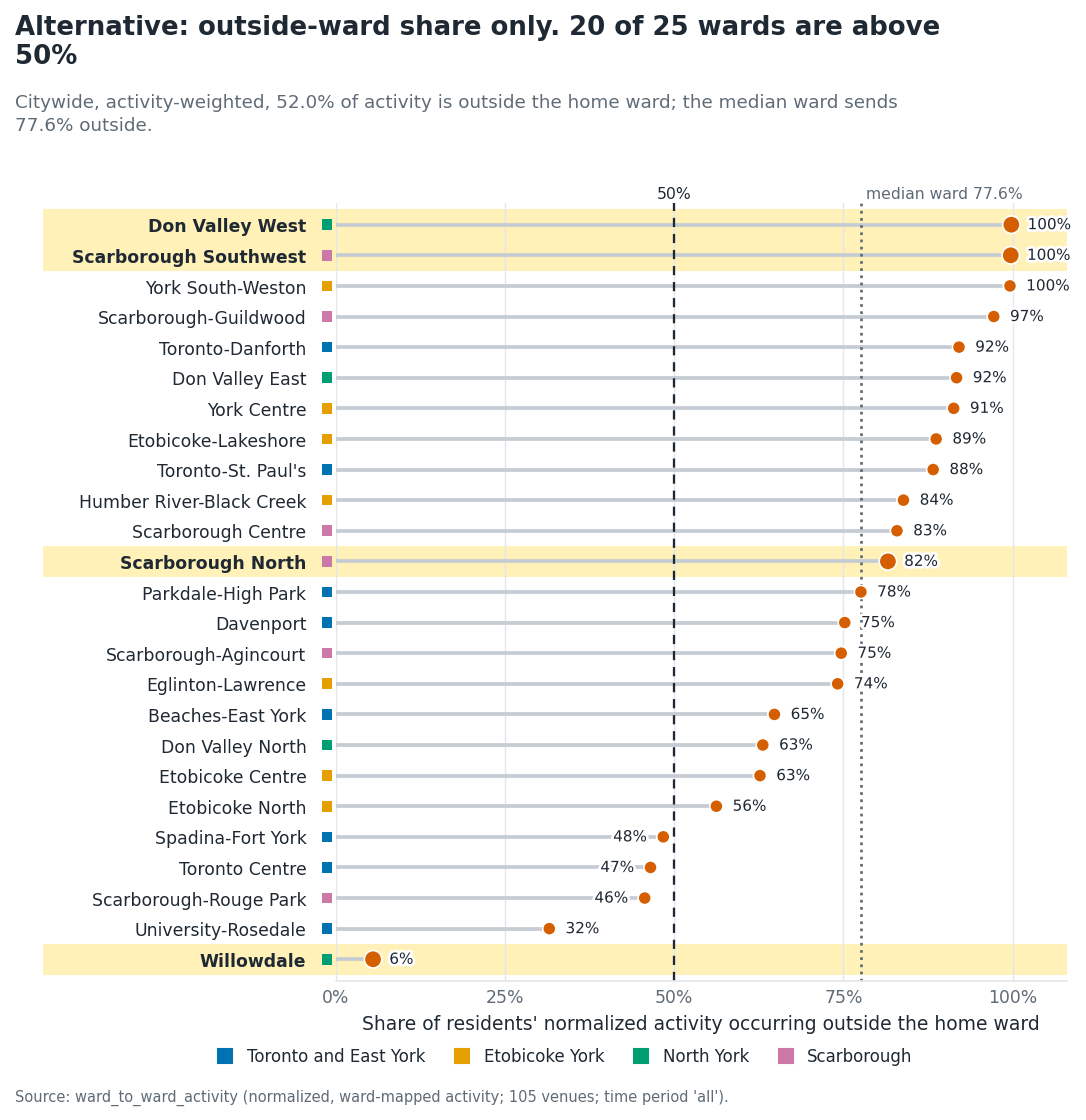

In [7]:
def plot_outside_lollipop(df):
    d = df.sort_values("origin_outside_share", ascending=True).reset_index(drop=True)
    wards, y = d["ward_name"].tolist(), np.arange(len(d))
    fig = plt.figure(figsize=(FIG_W, 7.4))
    top = title_block(fig, f"Alternative: outside-ward share only. {n_majority_outside} of 25 wards are above 50%",
                      f"Citywide, activity-weighted, {citywide_outside_share:.1%} of activity is outside the home ward; the median ward sends "
                      f"{median_outside_share:.1%} outside.")
    fig.subplots_adjust(left=0.30, right=0.95, top=top - 0.045, bottom=0.12)
    ax = fig.add_subplot(111)
    ax.set_xlim(0, 108)
    ax.set_ylim(-0.7, len(d) - 0.3)
    ax.set_yticks(y)
    ax.set_yticklabels(wards)
    highlight_rows(ax, wards, x0=-0.40)
    ax.hlines(y, 0, d["origin_outside_share"] * 100, color=LINK_COLOR, linewidth=1.8, zorder=1)
    ax.scatter(d["origin_outside_share"] * 100, y, s=np.where(d["ward_name"].isin(HIGHLIGHT_WARDS), 70, 40), color=OUTSIDE_COLOR,
               edgecolor=SURFACE, linewidth=0.8, zorder=3)
    for yi, v in zip(y, d["origin_outside_share"] * 100):
        near_line = 43 <= v < 50      # keep the label clear of the dashed 50% line
        ax.text(v - 2.4 if near_line else min(v + 2.4, 106), yi, f"{v:.0f}%", va="center", ha="right" if near_line else "left", fontsize=7.3,
                path_effects=HALO, zorder=4)
    ax.axvline(50, color=INK, linestyle=(0, (4, 3)), linewidth=1.1, zorder=2)
    ax.axvline(median_outside_share * 100, color=MUTED, linestyle=":", linewidth=1.3, zorder=2)
    ax.text(50, len(d) - 0.25, "50%", ha="center", va="bottom", fontsize=7.5, clip_on=False)
    ax.text(median_outside_share * 100 + 0.8, len(d) - 0.25, f"median ward {median_outside_share:.1%}", ha="left", va="bottom", fontsize=7.5,
            color=MUTED, clip_on=False)
    ax.tick_params(axis="y", pad=14)
    region_markers(ax, wards, x=-0.012)
    ax.xaxis.set_major_formatter(pct_fmt())
    ax.set_xticks(range(0, 101, 25))
    ax.set_xlabel("Share of residents' normalized activity occurring outside the home ward")
    style_axes(ax, "x")
    ax.spines["left"].set_visible(False)
    region_legend(fig, y=0.03)
    source_note(fig, "Source: ward_to_ward_activity (normalized, ward-mapped activity; 105 venues; time period 'all').", wrap=140)
    plt.show()


plot_outside_lollipop(ward_reach)

**What it shows.** The same outside-ward share as a sorted dot plot, with 50% and the median ward (77.6%) marked.

**Narrative claim.** Identical to the primary chart: a clear majority of wards sit to the right of 50%.

**Limitations.** Dropping the within-ward share removes useful composition. Willowdale (94% local) and University-Rosedale (68% local) look like low dots rather than strongly local wards, and the citywide activity-weighted figure has no natural place to sit.

**Primary vs. alternative.** The **primary version is stronger**. The dot plot is cleaner and makes ranking easier, which makes it a good compact fallback for a narrow web layout, but it loses the within/outside composition that makes the headline intuitive.

## 2. Wards as origins and destinations

**Claim to support:** every ward plays two roles at once. It is a source of residents’ activity (**origin side**) and a host of venues that draw activity in (**destination side**). The two are not the same number: a ward whose residents mostly go elsewhere can still draw heavily from outside.

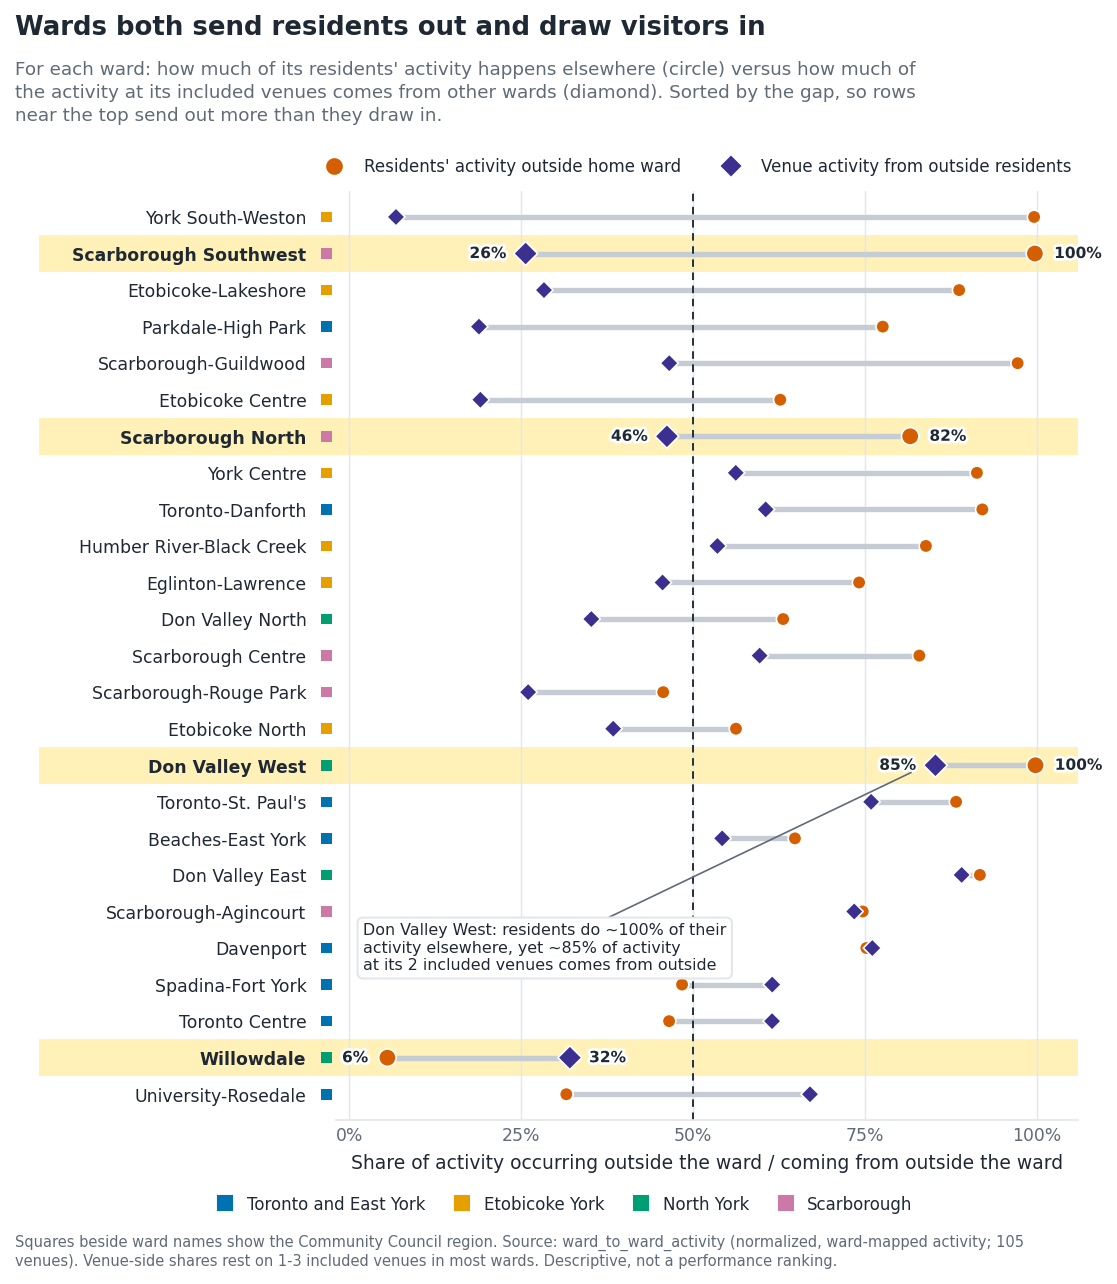

In [8]:
def plot_origin_destination_dumbbell(df, callout_ward="Don Valley West"):
    d = df.assign(gap=df["origin_outside_share"] - df["dest_outside_share"]).sort_values("gap", ascending=True).reset_index(drop=True)
    wards, y = d["ward_name"].tolist(), np.arange(len(d))
    fig = plt.figure(figsize=(FIG_W, 8.5))
    top = title_block(fig, "Wards both send residents out and draw visitors in",
                      "For each ward: how much of its residents' activity happens elsewhere (circle) versus how much of the activity at its included "
                      "venues comes from other wards (diamond). Sorted by the gap, so rows near the top send out more than they draw in.")
    fig.subplots_adjust(left=0.30, right=0.96, top=top - 0.035, bottom=0.125)
    ax = fig.add_subplot(111)
    ax.set_xlim(-2, 106)
    ax.set_ylim(-0.7, len(d) - 0.3)
    ax.set_yticks(y)
    ax.set_yticklabels(wards)
    highlight_rows(ax, wards, x0=-0.40)
    o, v = d["origin_outside_share"] * 100, d["dest_outside_share"] * 100
    ax.hlines(y, np.minimum(o, v), np.maximum(o, v), color=LINK_COLOR, linewidth=2.6, zorder=1)
    ax.axvline(50, color=INK, linestyle=(0, (4, 3)), linewidth=0.9, zorder=1)
    hl = d["ward_name"].isin(HIGHLIGHT_WARDS).values
    ax.scatter(o, y, s=np.where(hl, 70, 42), color=ORIGIN_COLOR, edgecolor=SURFACE, linewidth=0.8, zorder=3, marker="o")
    ax.scatter(v, y, s=np.where(hl, 66, 38), color=DEST_COLOR, edgecolor=SURFACE, linewidth=0.8, zorder=3, marker="D")
    for yi, ov, vv, h in zip(y, o, v, hl):
        if not h:
            continue
        for val, other in ((ov, vv), (vv, ov)):
            right = val >= other
            ax.text(val + (2.8 if right else -2.8), yi, f"{val:.0f}%", ha="left" if right else "right", va="center", fontsize=7.4,
                    fontweight="bold", path_effects=HALO, zorder=4)
    ax.tick_params(axis="y", pad=14)
    region_markers(ax, wards, x=-0.012)
    ax.xaxis.set_major_formatter(pct_fmt())
    ax.set_xticks(range(0, 101, 25))
    ax.set_xlabel("Share of activity occurring outside the ward / coming from outside the ward")
    style_axes(ax, "x")
    ax.spines["left"].set_visible(False)

    cw = d.set_index("ward_name").loc[callout_ward]
    cy = wards.index(callout_ward)
    ax.annotate(f"{callout_ward}: residents do ~{cw['origin_outside_share']:.0%} of their\nactivity elsewhere, yet ~{cw['dest_outside_share']:.0%} of activity\n"
                f"at its {cw['n_venues']} included venues comes from outside", xy=(cw["dest_outside_share"] * 100 - 3, cy - 0.15), xytext=(2, 4.0),
                fontsize=7.6, color=INK, ha="left", va="center", arrowprops=dict(arrowstyle="-", color=MUTED, linewidth=0.8, shrinkA=0, shrinkB=2),
                bbox=dict(boxstyle="round,pad=0.35", facecolor=SURFACE, edgecolor=GRID_COLOR), zorder=6)

    handles = [Line2D([0], [0], marker="o", linestyle="", color=ORIGIN_COLOR, markersize=7, label="Residents' activity outside home ward"),
               Line2D([0], [0], marker="D", linestyle="", color=DEST_COLOR, markersize=6, label="Venue activity from outside residents")]
    ax.legend(handles=handles, loc="lower right", bbox_to_anchor=(1.0, 1.01), ncol=2, fontsize=8, borderaxespad=0)
    region_legend(fig, y=0.04)
    source_note(fig, "Squares beside ward names show the Community Council region. Source: ward_to_ward_activity (normalized, ward-mapped activity; 105 "
                     "venues). Venue-side shares rest on 1-3 included venues in most wards. Descriptive, not a performance ranking.", wrap=135)
    plt.show()


plot_origin_destination_dumbbell(ward_reach)

**What it shows.** For each ward, the share of its residents’ activity that occurs outside the ward (circle) and the share of activity at its included venues that comes from outside residents (diamond). Wards are sorted by the gap between the two, so rows near the top send out more than they draw in and rows near the bottom draw in more than they send out.

**Narrative claim.** Wards differ in how they connect to the network, and a single in-versus-out number hides that. Don Valley West is the clearest example: residents do about 100% of their activity elsewhere, yet about 85% of activity at its two included venues comes from outside the ward. Willowdale sits at the other extreme, with residents who mostly stay local while venues draw about a third of their activity from elsewhere.

**Limitations.**
- Most wards have only 1–3 included venues, so the venue-side share is sensitive to which venues were sampled.
- The sort order is a descriptive device. It does not rank wards by quality or performance.
- Both measures are shares of normalized activity, not volumes: a high share can sit on a very small volume.

**Primary vs. alternative.** The dumbbell is the more legible of the two for a councillor audience because all 25 wards are named and the eye reads a short line between two dots. The quadrant (next) is better for explaining the roles, but only if a few wards are labelled.

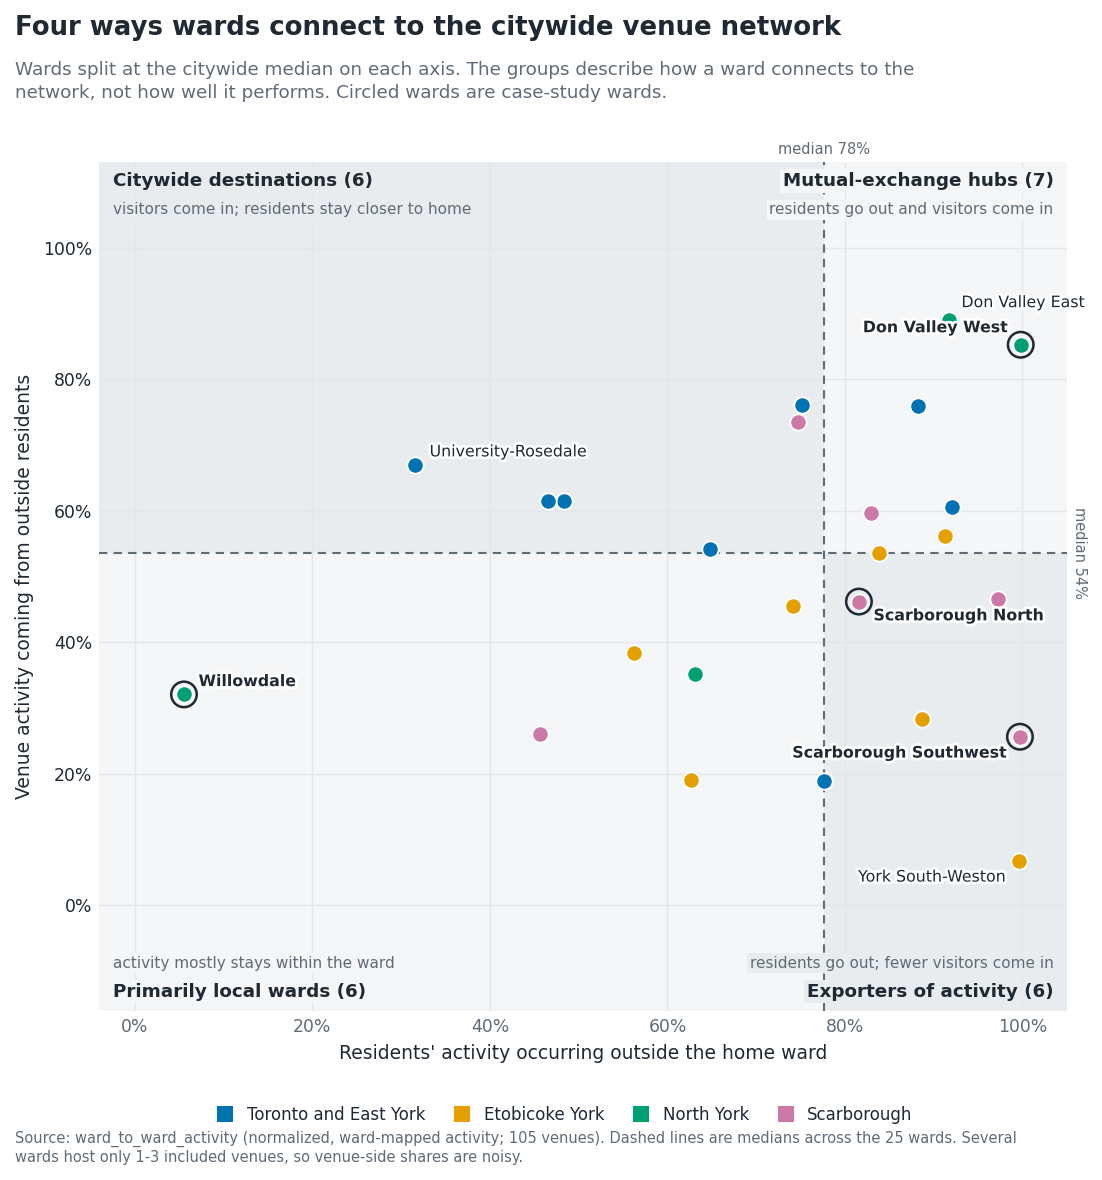

In [9]:
def plot_role_quadrant(df):
    lo, hi = -16, 113
    fig = plt.figure(figsize=(FIG_W, 7.8))
    top = title_block(fig, "Four ways wards connect to the citywide venue network",
                      "Wards split at the citywide median on each axis. The groups describe how a ward connects to the network, not how well it performs. "
                      "Circled wards are case-study wards.")
    fig.subplots_adjust(left=0.09, right=0.95, top=top - 0.035, bottom=0.14)
    ax = fig.add_subplot(111)
    x, yv = df["origin_outside_share"] * 100, df["dest_outside_share"] * 100
    mx, my = med_origin * 100, med_dest * 100
    ax.set_xlim(-4, 105)
    ax.set_ylim(lo, hi)
    tints = {"citywide destination": ((-4, my), mx + 4, hi - my), "mutual exchange hub": ((mx, my), 105 - mx, hi - my),
             "primarily local": ((-4, lo), mx + 4, my - lo), "exporter of activity": ((mx, lo), 105 - mx, my - lo)}
    tint_of = QUADRANT_TINTS
    for role, (xy, w, h) in tints.items():
        ax.add_patch(Rectangle(xy, w, h, facecolor=tint_of[role], edgecolor="none", zorder=0))
    ax.axvline(mx, color=MUTED, linestyle=(0, (4, 3)), linewidth=1, zorder=1)
    ax.axhline(my, color=MUTED, linestyle=(0, (4, 3)), linewidth=1, zorder=1)
    for region in REGION_ORDER:
        s = df["region"] == region
        ax.scatter(x[s], yv[s], s=62, color=REGION_COLORS[region], edgecolor=SURFACE, linewidth=0.9, zorder=3, label=region)
    hl = df[df["ward_name"].isin(HIGHLIGHT_WARDS)]
    ax.scatter(hl["origin_outside_share"] * 100, hl["dest_outside_share"] * 100, s=150, facecolor="none", edgecolor=INK, linewidth=1.2, zorder=4)
    for _, r in df[df["ward_name"].isin(QUADRANT_LABELLED)].iterrows():
        dx, dy, ha = QUADRANT_LABEL_OFFSETS.get(r["ward_name"], (6, 4, "left"))
        ax.annotate(r["ward_name"], (r["origin_outside_share"] * 100, r["dest_outside_share"] * 100), xytext=(dx, dy), textcoords="offset points",
                    ha=ha, fontsize=7.6, fontweight="bold" if r["ward_name"] in HIGHLIGHT_WARDS else "normal", path_effects=HALO, zorder=5)
    corners = {"citywide destination": (-2.5, hi - 1.5, "left", "top"), "mutual exchange hub": (103.5, hi - 1.5, "right", "top"),
               "primarily local": (-2.5, lo + 1.5, "left", "bottom"), "exporter of activity": (103.5, lo + 1.5, "right", "bottom")}
    blurbs = {"citywide destination": "visitors come in; residents stay closer to home", "mutual exchange hub": "residents go out and visitors come in",
              "primarily local": "activity mostly stays within the ward", "exporter of activity": "residents go out; fewer visitors come in"}
    for role, (cx, cy, ha, va) in corners.items():
        sign = -1 if va == "top" else 1
        back = dict(facecolor=tint_of[role], edgecolor="none", pad=1.2)
        ax.text(cx, cy, f"{ROLE_LABELS[role]} ({role_counts.get(role, 0)})", ha=ha, va=va, fontsize=8.8, fontweight="bold", zorder=2, bbox=back)
        ax.text(cx, cy + sign * 4.6, blurbs[role], ha=ha, va=va, fontsize=7.3, color=MUTED, zorder=2, bbox=back)
    ax.xaxis.set_major_formatter(pct_fmt())
    ax.yaxis.set_major_formatter(pct_fmt())
    ax.set_xticks(range(0, 101, 20))
    ax.set_yticks(range(0, 101, 20))
    ax.set_xlabel("Residents' activity occurring outside the home ward")
    ax.set_ylabel("Venue activity coming from outside residents")
    style_axes(ax, "both")
    ax.spines[["left", "bottom"]].set_visible(False)
    ax.text(mx, hi + 0.8, f"median {mx:.0f}%", ha="center", va="bottom", fontsize=7, color=MUTED, clip_on=False)
    ax.text(105.6, my, f"median {my:.0f}%", ha="left", va="center", fontsize=7, color=MUTED, rotation=-90, clip_on=False)
    region_legend(fig, y=0.03)
    source_note(fig, "Source: ward_to_ward_activity (normalized, ward-mapped activity; 105 venues). Dashed lines are medians across the 25 wards. "
                     "Several wards host only 1-3 included venues, so venue-side shares are noisy.", wrap=135)
    plt.show()


plot_role_quadrant(ward_reach)

**What it shows.** Each ward as a point: residents’ outside-ward share on the x-axis and venues’ outside-origin share on the y-axis, split at the citywide medians into four roles. The classification gives **7 mutual-exchange hubs, 6 citywide destinations, 6 exporters of activity and 6 primarily local wards**, matching the reference notebook.

**Narrative claim.** Every region contains wards playing more than one role, which supports a **network** framing rather than a core-versus-periphery one. The roles are descriptive labels for how a ward connects to the network, not a performance ranking, so the quadrants use neutral tints.

**Limitations.** Median splits create sharp boundaries from continuous data, so wards near a line could fall either way. Only seven wards are labelled; the rest are readable only by region colour. Don Valley West is a mutual-exchange hub partly because of a thin venue sample.

**Primary vs. alternative.** The **dumbbell is stronger as the primary supporting graphic**. The quadrant is a good *concept* graphic for the four roles and works best on a web page where hovering can name every point.

## 3. Distance as a companion graphic

This is a small companion to the origin/destination chart, not a standalone section. It answers a natural question: **does crossing a ward boundary mean travelling across the city?** Distances are straight-line, from the centre of each home geohash6 cell (about 1 km across) to the venue, weighted by normalized activity.

In [10]:
# --- straight-line home-area -> venue distances, weighted by normalized activity ---------
homes_dist = build_home_distances()
homes_dist["same_ward"] = homes_dist["origin_ward"] == homes_dist["dest_ward"]
homes_dist["origin_region"] = homes_dist["origin_ward"].map(region_of)
homes_dist["dest_region"] = homes_dist["dest_ward"].map(region_of)
W = "normalized_raw_stop_count"

is_suburban_origin = homes_dist["origin_region"] != "Downtown/core"
distance_groups = {
    "Within home ward": homes_dist[homes_dist["same_ward"]],
    "All cross-ward activity": homes_dist[~homes_dist["same_ward"]],
    "Suburb to suburb": homes_dist[is_suburban_origin & (homes_dist["dest_region"] != "Downtown/core") & ~homes_dist["same_ward"]],
    "Suburb to downtown": homes_dist[is_suburban_origin & (homes_dist["dest_region"] == "Downtown/core")],
}
distance_summary = pd.DataFrame({k: weighted_quantiles(v, "distance_km", W) for k, v in distance_groups.items()}).T
distance_summary.columns = ["p25_km", "median_km", "p75_km"]

# share of suburban residents' outside-ward activity that goes to another suburban ward
outside_flows = ward_to_ward_activity[~ward_to_ward_activity["same_ward"]].copy()
outside_flows["origin_region"] = outside_flows["origin_ward"].map(region_of)
outside_flows["dest_region"] = outside_flows["dest_ward"].map(region_of)
sub_origin = outside_flows[outside_flows["origin_region"] != "Downtown/core"]
suburban_stays_suburban = sub_origin.loc[sub_origin["dest_region"] != "Downtown/core", VALUE_COL].sum() / sub_origin[VALUE_COL].sum()

display(distance_summary.round(2))
print(f"suburban residents' outside-ward activity going to another suburban ward: {suburban_stays_suburban:.1%}")

checks_3 = run_checks([
    ("median distance, within home ward (km)", distance_summary.loc["Within home ward", "median_km"]),
    ("median distance, all cross-ward (km)", distance_summary.loc["All cross-ward activity", "median_km"]),
    ("median distance, suburb-to-suburb (km)", distance_summary.loc["Suburb to suburb", "median_km"]),
    ("median distance, suburb-to-downtown (km)", distance_summary.loc["Suburb to downtown", "median_km"]),
    ("suburban outside-ward activity staying suburban", suburban_stays_suburban),
])

decoding home geohash6 cells:   0%|          | 0/1187 [00:00<?, ?it/s]

home cells with no ward match (excluded from distance summaries): 291 / 14745 rows


,p25_km,median_km,p75_km
Within home ward,0.080,0.330,0.870
All cross-ward activity,2.410,6.220,11.050
Suburb to suburb,3.550,6.570,11.900
Suburb to downtown,8.540,11.310,13.960


suburban residents' outside-ward activity going to another suburban ward: 46.2%


check,computed,expected,status
"median distance, within home ward (km)",0.332,0.300,OK
"median distance, all cross-ward (km)",6.219,6.200,OK
"median distance, suburb-to-suburb (km)",6.570,6.600,OK
"median distance, suburb-to-downtown (km)",11.312,11.300,OK
suburban outside-ward activity staying suburban,0.462,0.460,OK


5/5 validation checks within tolerance


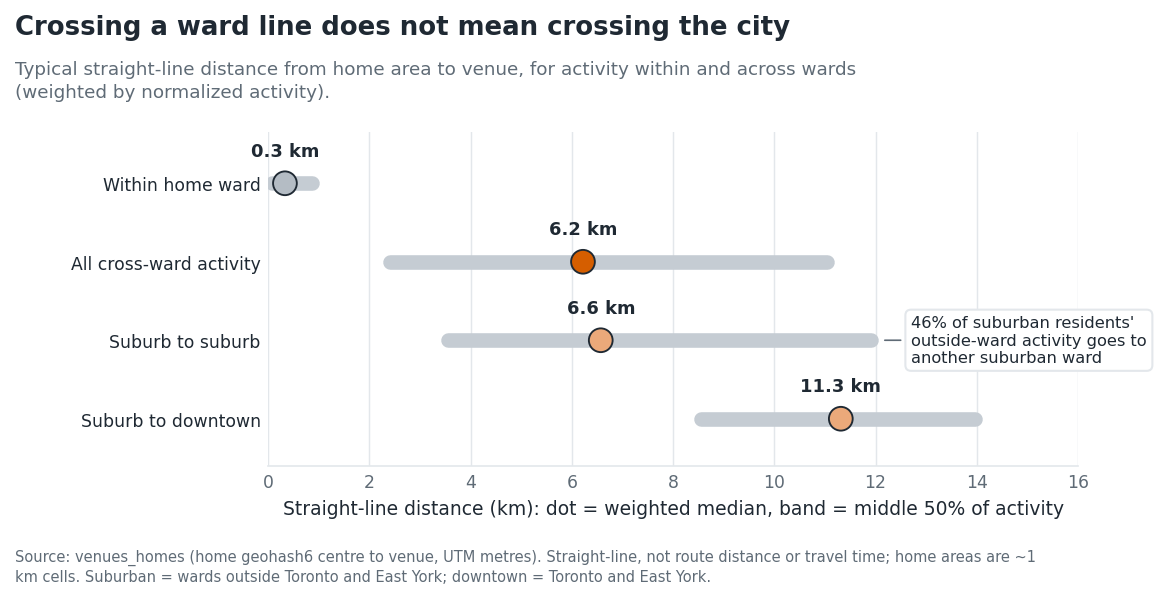

In [11]:
def plot_distance_companion(summary, suburb_share):
    order = ["Within home ward", "All cross-ward activity", "Suburb to suburb", "Suburb to downtown"]
    colors = [WITHIN_COLOR, OUTSIDE_COLOR, OUTSIDE_COLOR_LIGHT, OUTSIDE_COLOR_LIGHT]
    s = summary.loc[order]
    y = np.arange(len(order))[::-1]
    fig = plt.figure(figsize=(FIG_W, 3.9))
    top = title_block(fig, "Crossing a ward line does not mean crossing the city",
                      "Typical straight-line distance from home area to venue, for activity within and across wards (weighted by normalized activity).")
    fig.subplots_adjust(left=0.24, right=0.96, top=top - 0.02, bottom=0.21)
    ax = fig.add_subplot(111)
    ax.set_xlim(0, 16)
    ax.set_ylim(-0.6, len(order) - 0.35)
    ax.hlines(y, s["p25_km"], s["p75_km"], color=LINK_COLOR, linewidth=7, zorder=1, capstyle="round")
    ax.scatter(s["median_km"], y, s=130, color=colors, edgecolor=INK, linewidth=0.9, zorder=3)
    for yi, (name, r) in zip(y, s.iterrows()):
        ax.text(r["median_km"], yi + 0.30, f"{r['median_km']:.1f} km", ha="center", va="bottom", fontsize=8.6, fontweight="bold")
    ax.set_yticks(y)
    ax.set_yticklabels(order)
    ax.set_xlabel("Straight-line distance (km): dot = weighted median, band = middle 50% of activity")
    ax.set_xticks(range(0, 17, 2))
    style_axes(ax, "x")
    ax.spines["left"].set_visible(False)
    ax.annotate(f"{suburb_share:.0%} of suburban residents'\noutside-ward activity goes to\nanother suburban ward", xy=(s.loc["Suburb to suburb", "p75_km"] + 0.2, y[2]),
                xytext=(12.7, y[2]), fontsize=7.8, va="center", ha="left",
                arrowprops=dict(arrowstyle="-", color=MUTED, linewidth=0.8), bbox=dict(boxstyle="round,pad=0.35", facecolor=SURFACE, edgecolor=GRID_COLOR))
    source_note(fig, "Source: venues_homes (home geohash6 centre to venue, UTM metres). Straight-line, not route distance or travel time; home areas are "
                     "~1 km cells. Suburban = wards outside Toronto and East York; downtown = Toronto and East York.", wrap=135)
    plt.show()


plot_distance_companion(distance_summary, suburban_stays_suburban)

**What it shows.** Weighted median straight-line distance (dot) and the middle 50% of activity (band) for within-ward activity (0.3 km), all cross-ward activity (6.2 km), suburb-to-suburb activity (6.6 km) and suburb-to-downtown activity (11.3 km). The callout notes that about 46% of suburban residents’ outside-ward activity goes to another suburban ward.

**Narrative claim.** Crossing a ward boundary is a modest trip for most activity, and suburban residents’ cross-ward activity is frequently suburban rather than downtown-bound. The typical suburb-to-suburb trip is about 5 km shorter than the typical suburb-to-downtown one.

**Limitations.**
- Straight-line, not route distance or travel time. Transit access could make a shorter distance harder than a longer one.
- Home areas are roughly 1 km cells, so the 0.3 km within-ward median is approximate.
- About 2% of home-area rows (291 of 14,745) could not be matched to a ward and are excluded.
- The 46% is conditional on activity having already left the home ward, not a share of all activity,. The reference analysis also finds that much of the cross-region suburban flow runs into Willowdale (Meridian Arts Centre), with little flowing back.

**Primary vs. alternative.** Keep this as a **small companion beside the dumbbell** rather than a standalone figure. Four dots carry the point and nothing more is needed.

## 4. Scarborough destination composition

**Claim to support:** Scarborough is not one pattern. Residents’ activity is divided into five destination groups, in a fixed order from most local to least: within the home ward, another Scarborough ward, North York / Willowdale, downtown / core (the Toronto and East York wards), and elsewhere in Toronto. Group colours reuse the region colours of their destinations.

In [12]:
# --- Scarborough destination composition (residents' activity, by destination bucket) -----
scarb_flow = ward_to_ward_activity[ward_to_ward_activity["origin_ward"].isin(SCARBOROUGH_WARDS)].copy()
scarb_flow["bucket"] = [scarborough_bucket(d, o) for d, o in zip(scarb_flow["dest_ward"], scarb_flow["origin_ward"])]
scarb_comp = scarb_flow.groupby(["origin_ward", "bucket"])[VALUE_COL].sum().unstack(fill_value=0).reindex(columns=SCARB_BUCKETS, fill_value=0)
scarb_comp_share = scarb_comp.div(scarb_comp.sum(axis=1), axis=0)
display((scarb_comp_share * 100).round(1))

# --- internal network statistics -----------------------------------------------------------
scarb_internal = scarb_flow[scarb_flow["bucket"].isin(["other Scarborough"])]
received_internal = scarb_internal.groupby("dest_ward")[VALUE_COL].sum().sort_values(ascending=False)
pair = ward_to_ward_activity.pivot(index="origin_ward", columns="dest_ward", values=VALUE_COL)
north_to_agincourt = pair.loc["Scarborough North", "Scarborough-Agincourt"]
agincourt_to_north = pair.loc["Scarborough-Agincourt", "Scarborough North"]
reciprocity_north_agincourt = min(north_to_agincourt, agincourt_to_north) / max(north_to_agincourt, agincourt_to_north)

scarb_dest = ward_to_venue_activity[ward_to_venue_activity["dest_ward"].isin(SCARBOROUGH_WARDS)]
venue_totals = scarb_dest.groupby(["venue_id", "venue_name"])[VALUE_COL].sum().sort_values(ascending=False)
top_venue_id, top_venue_name = venue_totals.index[0]
top_venue_share = venue_totals.iloc[0] / venue_totals.sum()
ex_top = scarb_dest[scarb_dest["venue_id"] != top_venue_id]
ex_top_internal_share = ex_top.loc[ex_top["origin_ward"].isin(SCARBOROUGH_WARDS) & (ex_top["origin_ward"] != ex_top["dest_ward"]), VALUE_COL].sum() \
    / ex_top.loc[ex_top["origin_ward"].isin(SCARBOROUGH_WARDS), VALUE_COL].sum()

print(f"largest Scarborough venue: {top_venue_name} ({top_venue_share:.1%} of Scarborough-destination activity); "
      f"other-Scarborough share excluding it: {ex_top_internal_share:.1%}")

# --- Scarborough-origin distance by destination bucket ---------------------------------------
scarb_dist = homes_dist[homes_dist["origin_ward"].isin(SCARBOROUGH_WARDS)].copy()
scarb_dist["bucket"] = [scarborough_bucket(d, o) for d, o in zip(scarb_dist["dest_ward"], scarb_dist["origin_ward"])]
scarb_dist_summary = pd.DataFrame({b: weighted_quantiles(g, "distance_km", W) for b, g in scarb_dist.groupby("bucket")}).T
scarb_dist_summary.columns = ["p25_km", "median_km", "p75_km"]
display(scarb_dist_summary.reindex(SCARB_BUCKETS).round(2))

checks_4_6 = run_checks([
    ("Scarborough North -> other Scarborough", scarb_comp_share.loc["Scarborough North", "other Scarborough"]),
    ("Scarborough North -> North York/Willowdale", scarb_comp_share.loc["Scarborough North", "North York / Willowdale"]),
    ("Scarborough North -> downtown", scarb_comp_share.loc["Scarborough North", "downtown"]),
    ("Scarborough-Agincourt received from other Scarborough", received_internal["Scarborough-Agincourt"]),
    ("Scarborough Centre received from other Scarborough", received_internal["Scarborough Centre"]),
    ("Scarborough North -> Scarborough-Agincourt", north_to_agincourt),
    ("reciprocity, Scarborough North <-> Agincourt", reciprocity_north_agincourt),
    ("Malvern Library share of Scarborough-destination activity", top_venue_share),
    ("other-Scarborough share excluding Malvern Library", ex_top_internal_share),
    ("Scarborough residents' median distance: other Scarborough (km)", scarb_dist_summary.loc["other Scarborough", "median_km"]),
    ("Scarborough residents' median distance: North York/Willowdale (km)", scarb_dist_summary.loc["North York / Willowdale", "median_km"]),
    ("Scarborough residents' median distance: downtown (km)", scarb_dist_summary.loc["downtown", "median_km"]),
])

bucket,same ward,other Scarborough,North York / Willowdale,downtown,elsewhere in Toronto
origin_ward,,,,,
Scarborough Centre,17.100,11.600,19.400,50.200,1.700
Scarborough North,18.400,38.300,22.100,20.100,1.100
Scarborough Southwest,0.300,7.800,10.900,79.600,1.400
Scarborough-Agincourt,25.300,6.400,33.600,32.200,2.500
Scarborough-Guildwood,2.800,25.600,22.800,45.600,3.200
Scarborough-Rouge Park,54.400,5.900,16.100,22.800,0.800


largest Scarborough venue: Malvern Library (34.6% of Scarborough-destination activity); other-Scarborough share excluding it: 55.3%


,p25_km,median_km,p75_km
same ward,0.310,0.880,1.910
other Scarborough,2.050,4.300,5.920
North York / Willowdale,9.540,12.450,14.890
downtown,10.260,13.480,17.450
elsewhere in Toronto,16.460,19.970,24.240


check,computed,expected,status
Scarborough North -> other Scarborough,0.383,0.383,OK
Scarborough North -> North York/Willowdale,0.221,0.221,OK
Scarborough North -> downtown,0.201,0.201,OK
Scarborough-Agincourt received from other Scarborough,681.401,681.000,OK
Scarborough Centre received from other Scarborough,447.075,447.000,OK
Scarborough North -> Scarborough-Agincourt,282.052,283.000,OK
"reciprocity, Scarborough North <-> Agincourt",0.094,0.090,OK
Malvern Library share of Scarborough-destination activity,0.346,0.346,OK
other-Scarborough share excluding Malvern Library,0.553,0.553,OK
Scarborough residents' median distance: other Scarborough (km),4.302,4.300,OK


12/12 validation checks within tolerance


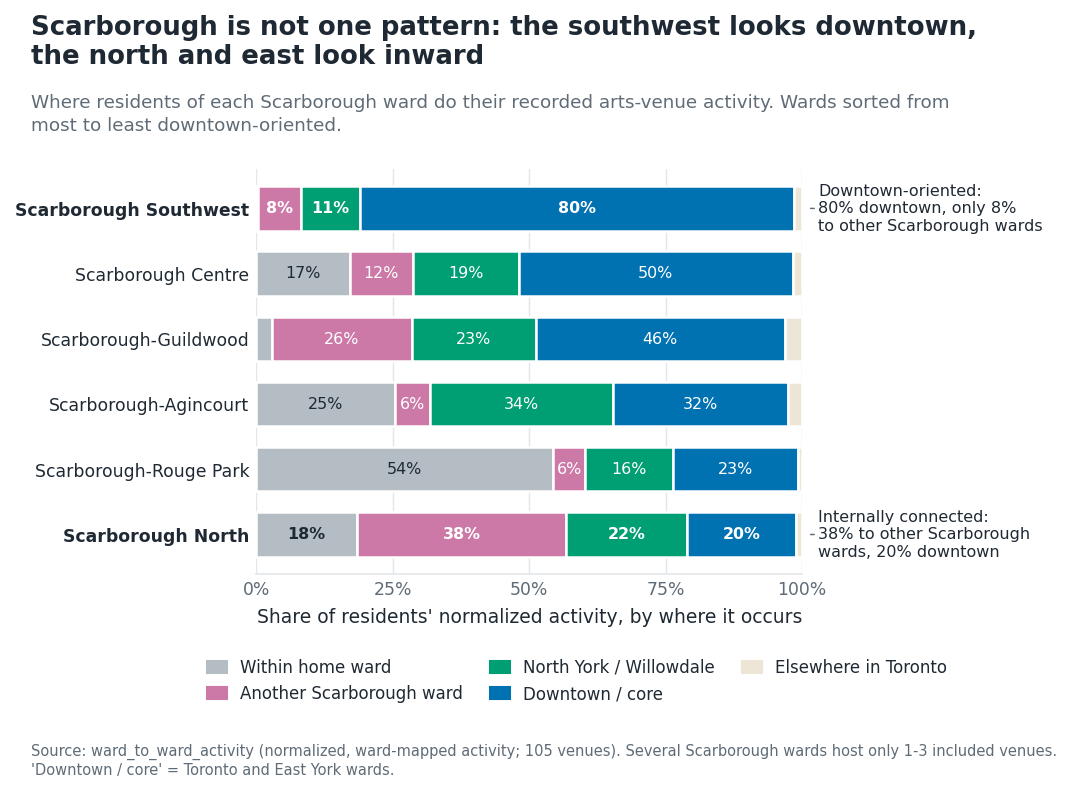

In [13]:
def plot_scarborough_composition(comp_share):
    order = comp_share["downtown"].sort_values(ascending=True).index.tolist()        # most downtown-oriented ends up at the top
    d = comp_share.loc[order]
    y = np.arange(len(d))
    fig = plt.figure(figsize=(FIG_W, 5.2))
    top = title_block(fig, "Scarborough is not one pattern: the southwest looks downtown, the north and east look inward",
                      "Where residents of each Scarborough ward do their recorded arts-venue activity. Wards sorted from most to least downtown-oriented.")
    fig.subplots_adjust(left=0.215, right=0.70, top=top - 0.02, bottom=0.27)
    ax = fig.add_subplot(111)
    ax.set_ylim(-0.6, len(d) - 0.4)
    ax.set_xlim(0, 100)
    left = np.zeros(len(d))
    for b in SCARB_BUCKETS:
        vals = d[b].values * 100
        ax.barh(y, vals, left=left, height=0.68, color=SCARB_BUCKET_COLORS[b], edgecolor=SURFACE, linewidth=1.2, label=SCARB_BUCKET_LABELS[b], zorder=2)
        for yi, v, l in zip(y, vals, left):
            if v >= 5.5:
                dark = b in ("same ward", "elsewhere in Toronto")
                ax.text(l + v / 2, yi, f"{v:.0f}%", ha="center", va="center", fontsize=7.6, color=INK if dark else "white", zorder=3,
                        fontweight="bold" if d.index[int(yi)] in HIGHLIGHT_WARDS else "normal")
        left += vals
    ax.set_yticks(y)
    ax.set_yticklabels(order)
    for lab in ax.get_yticklabels():
        if lab.get_text() in HIGHLIGHT_WARDS:
            lab.set_fontweight("bold")
    ax.xaxis.set_major_formatter(pct_fmt())
    ax.set_xticks(range(0, 101, 25))
    ax.set_xlabel("Share of residents' normalized activity, by where it occurs")
    style_axes(ax, "x")
    ax.spines["left"].set_visible(False)

    def margin_note(ward, text):
        yi = order.index(ward)
        ax.annotate(text, xy=(100.8, yi), xycoords="data", xytext=(1.03, yi), textcoords=ax.get_yaxis_transform(), fontsize=7.7, va="center", ha="left",
                    arrowprops=dict(arrowstyle="-", color=MUTED, linewidth=0.7, shrinkA=0), annotation_clip=False)
    sw, nn = "Scarborough Southwest", "Scarborough North"
    margin_note(sw, f"Downtown-oriented:\n{comp_share.loc[sw, 'downtown']:.0%} downtown, only {comp_share.loc[sw, 'other Scarborough']:.0%}\nto other Scarborough wards")
    margin_note(nn, f"Internally connected:\n{comp_share.loc[nn, 'other Scarborough']:.0%} to other Scarborough\nwards, {comp_share.loc[nn, 'downtown']:.0%} downtown")

    handles = [Patch(color=SCARB_BUCKET_COLORS[b], label=SCARB_BUCKET_LABELS[b]) for b in SCARB_BUCKETS]
    fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 0.085), ncol=3, fontsize=8, handlelength=1.2, columnspacing=1.6)
    source_note(fig, "Source: ward_to_ward_activity (normalized, ward-mapped activity; 105 venues). Several Scarborough wards host only 1-3 included venues. "
                     "'Downtown / core' = Toronto and East York wards.", wrap=135)
    plt.show()


plot_scarborough_composition(scarb_comp_share)

**What it shows.** One 100% bar per Scarborough ward, sorted from the most downtown-oriented (top) to the least. Scarborough North sends 38.3% of its residents’ activity to other Scarborough wards, 22.1% to North York / Willowdale and 20.1% downtown. Scarborough Southwest sends 79.6% downtown and only 7.8% to other Scarborough wards.

**Narrative claim.** Scarborough has a **downtown-oriented southwest** (Southwest 80% and Centre 50% downtown) alongside wards that look inward: Scarborough North and Guildwood send the most activity to other Scarborough wards (38% and 26%), while Rouge Park and Agincourt keep the most within their own ward (54% and 25%). The story should therefore be scoped to the wards that fit each pattern, not stated for “Scarborough” as a whole.

**Limitations.**
- Scarborough Southwest, Scarborough-Rouge Park and Scarborough-Agincourt each have a single included venue, so their within-ward shares mostly describe that one venue.
- About 27 of Scarborough-Agincourt’s 34 points going to North York / Willowdale are to Willowdale alone, where Meridian Arts Centre is one of only two included venues.
- Shares describe where sampled activity occurs, not what is available or preferred.

**Primary vs. alternative.** The stacked bar is the **strongest Scarborough graphic**. It carries the southwest-versus-north contrast with no extra explanation and uses the same colours as the rest of the notebook.

## 5. Alternative: Scarborough flow map

An exploratory alternative to the stacked bars. Only the strongest Scarborough-internal flows are drawn so the map does not become a hairball, and arrows join ward representative points (a point guaranteed to lie inside each polygon), not venue locations. The six public and cultural destinations were matched by exact venue name in the 105-venue sample.

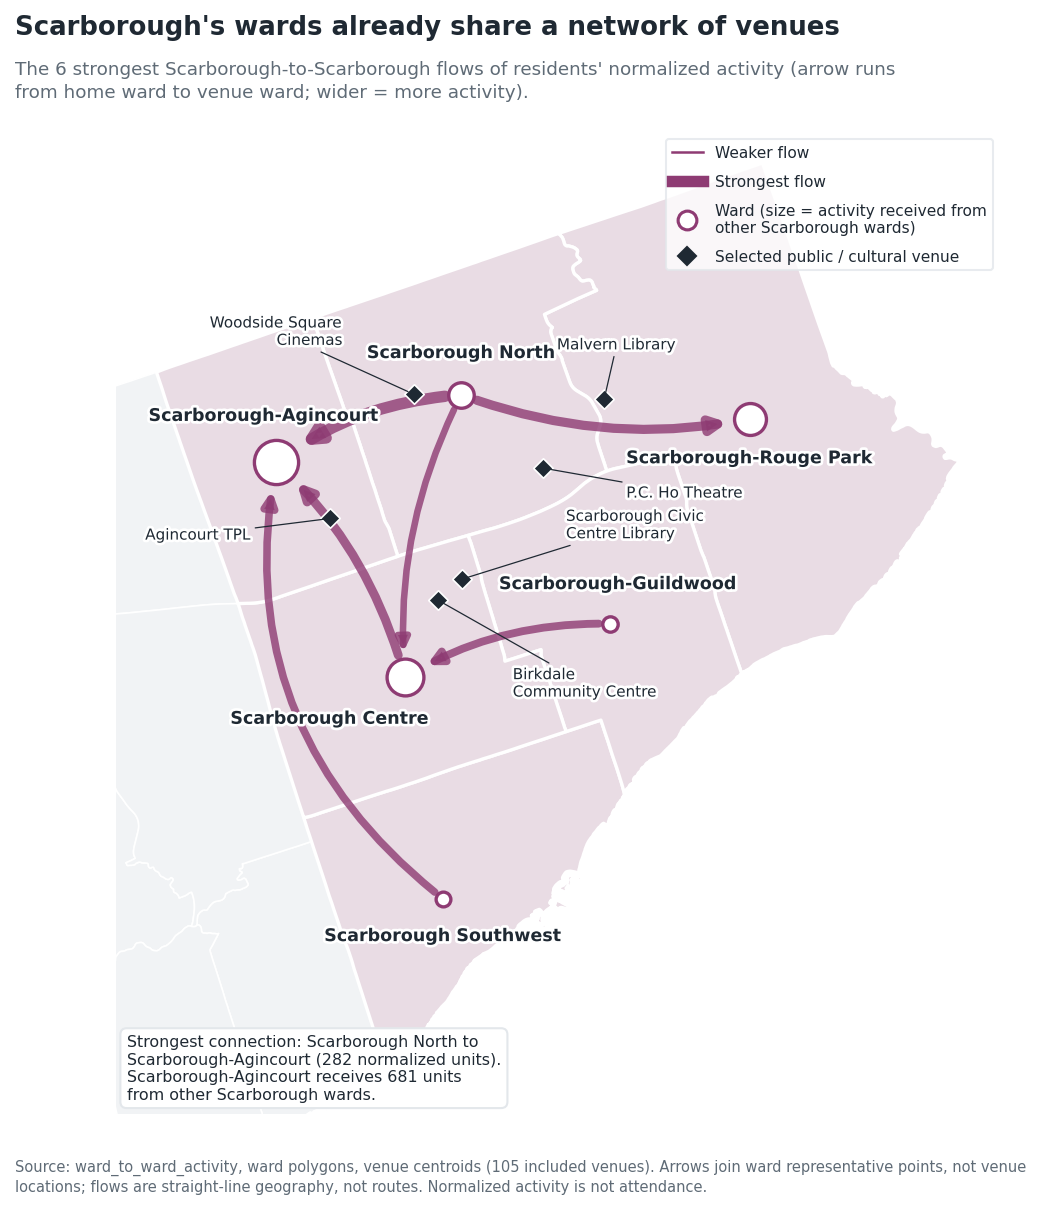

In [14]:
def plot_scarborough_flow_map(top_n=FLOW_MAP_TOP_N):
    sc = wards_gdf[wards_gdf["ward_name"].isin(SCARBOROUGH_WARDS)].to_crs(UTM_CRS).set_index("ward_name")
    context = wards_gdf[~wards_gdf["ward_name"].isin(SCARBOROUGH_WARDS)].to_crs(UTM_CRS)
    cxy = {w: (p.x, p.y) for w, p in sc.geometry.representative_point().items()}       # point guaranteed inside each ward

    fig = plt.figure(figsize=(FIG_W, 8.0))
    top = title_block(fig, "Scarborough's wards already share a network of venues",
                      f"The {top_n} strongest Scarborough-to-Scarborough flows of residents' normalized activity (arrow runs from home ward to venue ward; "
                      "wider = more activity).")
    fig.subplots_adjust(left=0.01, right=0.99, top=top - 0.005, bottom=0.075)
    ax = fig.add_subplot(111)
    context.plot(ax=ax, facecolor=MAP_CONTEXT_FILL, edgecolor="white", linewidth=0.8, zorder=0)
    sc.plot(ax=ax, facecolor=MAP_SCARB_FILL, edgecolor="white", linewidth=1.6, zorder=1)
    minx, miny, maxx, maxy = sc.total_bounds
    padx, pady = (maxx - minx) * 0.05, (maxy - miny) * 0.04
    ax.set_xlim(minx - padx, maxx + padx)
    ax.set_ylim(miny - pady, maxy + pady)
    ax.set_axis_off()

    flows = scarb_internal.groupby(["origin_ward", "dest_ward"])[VALUE_COL].sum().sort_values(ascending=False).head(top_n).reset_index()
    vmax = flows[VALUE_COL].max()
    recv = received_internal.reindex(SCARBOROUGH_WARDS).fillna(0)
    amin, amax = FLOW_MAP_NODE_AREA
    node_area = amin + (amax - amin) * (recv / recv.max())
    for _, f in flows.iterrows():
        lw = 1.0 + (FLOW_MAP_MAX_LW - 1.0) * f[VALUE_COL] / vmax
        ra, rb = np.sqrt(node_area[f["origin_ward"]] / np.pi), np.sqrt(node_area[f["dest_ward"]] / np.pi)
        ax.add_patch(FancyArrowPatch(cxy[f["origin_ward"]], cxy[f["dest_ward"]], connectionstyle=f"arc3,rad={FLOW_MAP_RAD.get((f['origin_ward'], f['dest_ward']), FLOW_MAP_DEFAULT_RAD)}", arrowstyle="-|>",
                                     mutation_scale=7 + 1.6 * lw, linewidth=lw, color=FLOW_COLOR, alpha=0.8, shrinkA=ra + 1, shrinkB=rb + 2, zorder=3))

    for w, (x, yv) in cxy.items():
        ax.scatter(x, yv, s=node_area[w], color=SURFACE, edgecolor=FLOW_COLOR, linewidth=1.6, zorder=4)
        dx, dy = SCARB_MAP_WARD_LABEL_OFFSETS[w]
        ax.annotate(w, (x, yv), xytext=(dx, dy), textcoords="offset points", ha="center", va="center", fontsize=8.4, fontweight="bold",
                    path_effects=HALO, zorder=7)

    for name, (label, dx, dy, ha) in SCARB_MAP_VENUES.items():       # exact-name matches only
        row = venue_points[venue_points["venue_name"] == name]
        assert len(row) == 1, f"could not match venue reliably: {name}"
        px, py = row.to_crs(UTM_CRS).geometry.iloc[0].coords[0]
        ax.scatter(px, py, s=44, marker="D", color=INK, edgecolor=SURFACE, linewidth=0.8, zorder=5)
        ax.annotate(label, (px, py), xytext=(dx, dy), textcoords="offset points", ha=ha, va="center", fontsize=7.3, path_effects=HALO, zorder=7,
                    arrowprops=dict(arrowstyle="-", color=INK, linewidth=0.6, shrinkA=0, shrinkB=3))

    top_flow = flows.iloc[0]
    ax.text(0.012, 0.012, f"Strongest connection: {top_flow['origin_ward']} to\n{top_flow['dest_ward']} ({top_flow[VALUE_COL]:.0f} normalized units).\n"
                          f"{received_internal.index[0]} receives {received_internal.iloc[0]:.0f} units\nfrom other Scarborough wards.",
            transform=ax.transAxes, fontsize=7.6, va="bottom", ha="left", bbox=dict(boxstyle="round,pad=0.4", facecolor=SURFACE, edgecolor=GRID_COLOR), zorder=8)
    legend_items = [Line2D([0], [0], color=FLOW_COLOR, linewidth=1.2, label="Weaker flow"), Line2D([0], [0], color=FLOW_COLOR, linewidth=FLOW_MAP_MAX_LW, label="Strongest flow"),
                    Line2D([0], [0], marker="o", linestyle="", markerfacecolor=SURFACE, markeredgecolor=FLOW_COLOR, markeredgewidth=1.5, markersize=9,
                           label="Ward (size = activity received from\nother Scarborough wards)"),
                    Line2D([0], [0], marker="D", linestyle="", color=INK, markersize=6, label="Selected public / cultural venue")]
    ax.legend(handles=legend_items, loc="upper right", bbox_to_anchor=(0.995, 0.995), fontsize=7.4, labelspacing=0.9, frameon=True, facecolor=SURFACE, edgecolor=GRID_COLOR)
    source_note(fig, "Source: ward_to_ward_activity, ward polygons, venue centroids (105 included venues). Arrows join ward representative points, not venue "
                     "locations; flows are straight-line geography, not routes. Normalized activity is not attendance.", wrap=135)
    plt.show()


plot_scarborough_flow_map()

**What it shows.** The six strongest Scarborough-to-Scarborough flows, with line width scaled to normalized activity and node size scaled to activity received from other Scarborough wards. Four of the six labelled destinations are public facilities (Malvern Library, Scarborough Civic Centre Library, Birkdale Community Centre, Agincourt Toronto Public Library); the other two are P.C. Ho Theatre and Woodside Square Cinemas.

**Narrative claim.** Scarborough already contains a multi-ward network of arts venues and public facilities, with **Scarborough-Agincourt as the clearest regional node**.

**Secondary numbers (kept off the figure):**
- Scarborough-Agincourt receives about 681 normalized units from other Scarborough wards, Scarborough Centre about 447, Scarborough-Rouge Park about 314 and Scarborough North about 170.
- Scarborough North → Scarborough-Agincourt is the strongest internal connection at about 282 units, with low reciprocity (about 0.09), meaning Agincourt draws from its neighbour far more than it sends back.
- Malvern Library alone accounts for 34.6% of all Scarborough-destination activity. After excluding it, 55.3% of the remaining Scarborough-destination activity still comes from other Scarborough wards, so the network does not depend on one venue.

**Limitations.** Arrows join ward points, not venues, and cannot show routes. Only the strongest six flows are drawn, from a sample of 105 venues, so absent arrows do not mean absent activity. The map suits an illustrative role more than a precise one.

**Primary vs. alternative.** The map is **evocative but secondary**: it adds geography and places the public facilities, but it is busier and harder to read than the stacked bars. Use it as a supporting illustration, with the stacked bars as the evidence.

## 6. Scarborough distance comparison

A small companion to the composition bars: how far do Scarborough residents travel to reach venues in each destination group? Weighted by normalized activity and measured straight-line from home area to venue.

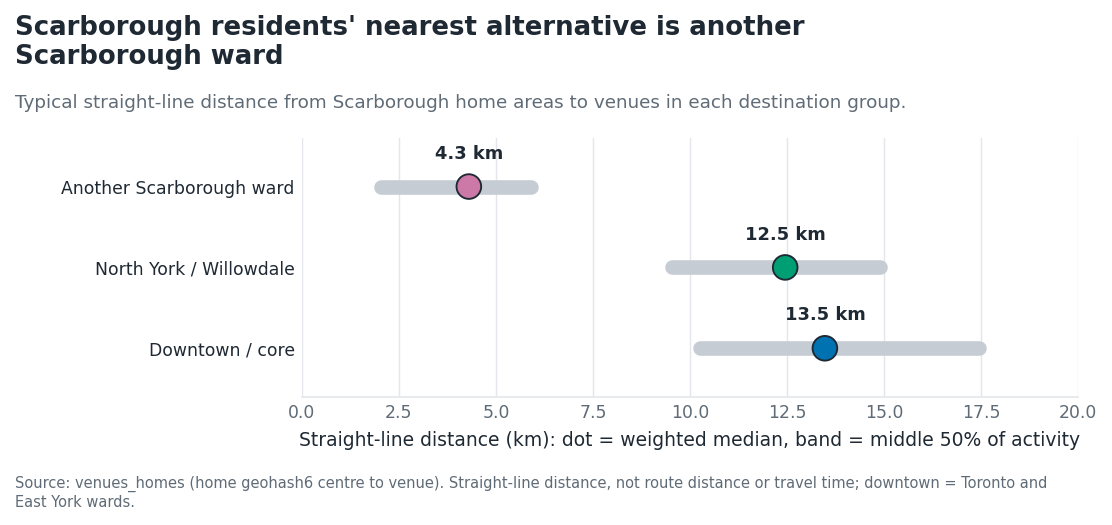

In [15]:
def plot_scarborough_distance(summary):
    rows = [("other Scarborough", "Another Scarborough ward"), ("North York / Willowdale", "North York / Willowdale"), ("downtown", "Downtown / core")]
    s = summary.loc[[r[0] for r in rows]]
    y = np.arange(len(rows))[::-1]
    fig = plt.figure(figsize=(FIG_W, 3.4))
    top = title_block(fig, "Scarborough residents' nearest alternative is another Scarborough ward",
                      "Typical straight-line distance from Scarborough home areas to venues in each destination group.")
    fig.subplots_adjust(left=0.27, right=0.96, top=top - 0.02, bottom=0.23)
    ax = fig.add_subplot(111)
    ax.set_xlim(0, 20)
    ax.set_ylim(-0.6, len(rows) - 0.4)
    ax.hlines(y, s["p25_km"], s["p75_km"], color=LINK_COLOR, linewidth=7, zorder=1, capstyle="round")
    ax.scatter(s["median_km"], y, s=140, color=[SCARB_BUCKET_COLORS[b] for b in s.index], edgecolor=INK, linewidth=0.9, zorder=3)
    for yi, (_, r) in zip(y, s.iterrows()):
        ax.text(r["median_km"], yi + 0.3, f"{r['median_km']:.1f} km", ha="center", va="bottom", fontsize=8.6, fontweight="bold")
    ax.set_yticks(y)
    ax.set_yticklabels([r[1] for r in rows])
    ax.set_xlabel("Straight-line distance (km): dot = weighted median, band = middle 50% of activity")
    style_axes(ax, "x")
    ax.spines["left"].set_visible(False)
    source_note(fig, "Source: venues_homes (home geohash6 centre to venue). Straight-line distance, not route distance or travel time; "
                     "downtown = Toronto and East York wards.", wrap=135)
    plt.show()


plot_scarborough_distance(scarb_dist_summary)

**What it shows.** Weighted median straight-line distance from Scarborough home areas to venues in another Scarborough ward (4.3 km), North York / Willowdale (12.5 km) and downtown (13.5 km).

**Narrative claim.** For Scarborough residents the closest alternative to a venue in their own ward is usually a venue in a *neighbouring Scarborough ward*, at about a third of the distance of a trip to North York or downtown. Scarborough already contains a multi-ward network of arts venues and public facilities, so strengthening an individual hub (for example in Agincourt, Centre or the north) could benefit several neighbouring wards.

**Limitations.** Straight-line distance and a sampled set of 105 venues (ten of them in Scarborough). It shows what residents *do* travel to, not what they would travel to if more venues existed nearby. The medians are weighted by the activity that was recorded.

**Primary vs. alternative.** Keep it small and place it directly under the composition bars, or fold the three medians into the caption. It is helpful but does not need a full-width figure.

## 7. Story 1 visual recommendation summary

| Role | Recommended graphic | Why |
|---|---|---|
| **Strongest headline graphic** | Section 1, stacked within/outside bar (primary) | The 50% line makes the claim visible immediately. It shows the within-ward share, includes a citywide bar, and lets every councillor find their own ward. |
| **Strongest supporting graphic** | Section 2, dumbbell, with the Section 3 distance chart as a small companion | Names all 25 wards, makes the origin/destination difference visible and avoids the labelling problem of a scatter plot. The distance chart shows that crossing a ward line is a modest trip. |
| **Strongest Scarborough case-study graphic** | Section 4, stacked destination composition | Carries the southwest-versus-north contrast without explanation and uses the shared colour language. |
| **Recommended alternative** | Section 2, quadrant scatter, for a web version | Best at explaining the four roles when hover labels can name every ward. The Section 5 flow map is a good illustrative companion to the Scarborough bars. |
| **Drop or merge** | The Section 1 dot plot (redundant with the stacked bar); fold the Section 6 distance medians into the Section 4 caption or an inset | The dot plot repeats the headline with less information. A full-width Section 6 chart repeats what a three-number caption already says. |